<a href="https://colab.research.google.com/github/sally03915/2026-AI-Analysis-Lab/blob/main/AI-FlowTransformation/Step1-Math/basic008_CrossEntropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 👨‍🍳 딥러닝 주방 특별 가이드: '요리의 맛'을 평가하고 발전시키기

우리 딥러닝 레스토랑의 주방장(모델)은 맛있는 요리(예측)를 만들고 싶어 합니다. 하지만 요리가 정말 맛있는지, 아니면 어떤 점을 고쳐야 할지 정확히 알아야겠죠? 손님(실제 정답)의 평가에 따라 요리 실력을 발전시켜야 하니까요.

이 가이드에서는 주방장(모델)이 요리(예측)를 평가받고, 그 평가를 통해 레시피(학습)를 개선하는 데 필요한 중요한 '비밀 도구'들을 소개할 거예요. 마치 음식 맛을 평가하는 심사위원처럼, 우리의 '크로스 엔트로피 손실 함수'는 요리가 정답 레시피에서 얼마나 벗어났는지, 그리고 얼마나 큰 벌점을 주어야 할지 정확히 알려줍니다.

때로는 여러 종류의 요리 중 하나를 고르는 '멀티 클래스' 요리 대회가 있고, 때로는 한 요리에 여러 맛이 나는 '멀티 라벨' 요리도 있어요. 주방장은 어떤 상황에서든 요리의 '실수'를 정확히 파악하고, 그 실수를 줄이기 위해 '재료를 어떻게 조절해야 할지' (미분) 배워야 합니다.

이 모든 과정을 통해 주방장은 작은 실수에도 크게 반응하고, 특히 '절대 틀려서는 안 되는' 부분에서 틀리면 어마어마한 벌점을 받으며 더욱 신중한 요리사가 됩니다. 함께 딥러닝 주방의 깊은 맛과 숨겨진 비밀을 파헤쳐 볼까요?

<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>


### 001: Logistic Regression Cost = Cross Entropy Loss  

### 👨‍🍳 요리 평가하기: '얼마나 틀렸을까?' - 크로스 엔트로피 손실 함수

우리 레스토랑의 주방장(모델)이 야심 차게 만든 요리(예측)가 손님(정답)의 입맛에 얼마나 맞는지 평가하는 시간입니다. 요리에는 정답 레시피가 있는데, 주방장이 만든 요리가 이 레시피에서 얼마나 벗어났는지 확인해야겠죠?

이때, 단순히 '조금 다르네?' 하고 넘어가는 것이 아니라, '정말 중요한 부분에서 크게 틀렸으면 벌점을 왕창 줘야 해!'라고 엄격하게 평가하는 방법이 있습니다. 바로 **크로스 엔트로피(Cross Entropy) 손실 함수**가 이 역할을 합니다. 이 함수는 요리(예측)가 정답 레시피에서 조금만 틀려도 벌점을 주고, 심하게 틀릴수록 벌점을 기하급수적으로 늘려, 주방장이 다음엔 더 정확한 요리를 만들도록 도와줍니다.  그래프를 따라치지 말고 실행해보세요!




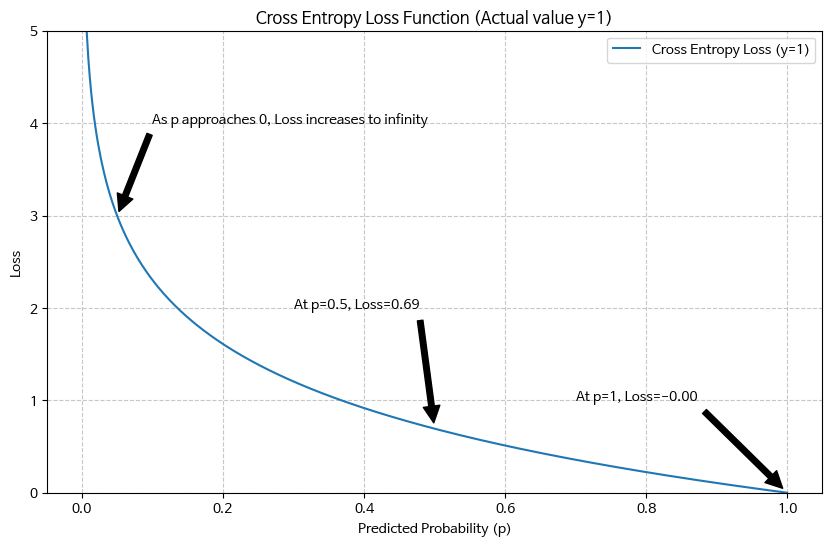

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set the range for the predicted probability (p). Start from a very small value
# as the loss diverges to infinity as p approaches 0.
p = np.linspace(0.001, 1, 500) # Generate 500 points from 0.001 to 1

# Cross Entropy Loss function when the actual answer is 1: -log(p)
loss_y_eq_1 = -np.log(p)

# Plot the graph
fig = plt.figure(figsize=(10, 6))
plt.plot(p, loss_y_eq_1, label='Cross Entropy Loss (y=1)')
plt.xlabel('Predicted Probability (p)')
plt.ylabel('Loss')
plt.title('Cross Entropy Loss Function (Actual value y=1)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 5) # Limit y-axis range for better visualization, excluding too high infinite values

# Add annotations for key points
plt.annotate(f'At p=1, Loss={-np.log(1):.2f}', xy=(1, -np.log(1)), xytext=(0.7, 1),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate(f'At p=0.5, Loss={-np.log(0.5):.2f}', xy=(0.5, -np.log(0.5)), xytext=(0.3, 2),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate('As p approaches 0, Loss increases to infinity', xy=(0.05, -np.log(0.05)), xytext=(0.1, 4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.legend()
plt.show()

### 그래프 해석: 실제 정답이 1일 때의 크로스 엔트로피 손실

위 그래프는 실제 정답 `y`가 1일 때 (즉, 손님이 '만족'한 경우), 주방장(모델)의 예측 확률 `p`에 따라 크로스 엔트로피 손실이 어떻게 변하는지 보여줍니다.

*   **예측 확률 `p`가 1에 가까워질수록 (오른쪽으로 갈수록):** 손실 값은 거의 0에 수렴합니다. 이는 모델이 정답을 매우 정확하게 예측했을 때 벌점이 거의 없다는 것을 의미합니다. 예를 들어, **`p=1`일 때 손실은 `0.00`** 으로 거의 0입니다.

*   **예측 확률 `p`가 0.5일 때:** **손실은 `0.69`** 입니다. 이는 모델이 정답인지 오답인지 '반반'으로 예측했을 때 받는 벌점입니다.

*   **예측 확률 `p`가 0에 가까워질수록 (왼쪽으로 갈수록):** 손실 값은 급격하게 증가하여 무한대로 발산합니다. 이는 모델이 실제 정답(`y=1`)인데도 불구하고, 정답이 아닐 것이라고 강하게 예측(`p`가 0에 가까움)하면 어마어마하게 큰 벌점을 받는다는 것을 나타냅니다. 예를 들어, 그래프에서 보이는 것처럼 **`p`가 0에 가까워지면 손실은 무한대로 증가**합니다.

이러한 손실 함수의 특성 덕분에, 딥러닝 모델은 학습 과정에서 실제 정답에 대해 잘못된 예측을 하는 경우 강력한 페널티를 받아, 점차 정확한 예측을 하는 방향으로 가중치를 조정하게 됩니다. 이는 "틀린 정도를 로그로 크게 벌주는" 크로스 엔트로피의 핵심 역할과 일맥상통합니다.

**수학적 의미:**  
$$
CE = -\sum_{i} t_i \log(f(s)_i)
$$  
Logistic Regression에서 사용하는 대표적인 손실 함수로, **Cross Entropy Loss**라고도 불립니다.

**생활 비유:**  
“정답과 예측이 얼마나 어긋났는지, 틀린 정도를 로그로 크게 벌주는 것 → 작은 실수는 덜, 큰 실수는 크게 반영.”  

**딥러닝 연결:**  
분류 문제에서 모델의 예측 확률과 실제 정답을 비교해 **학습 방향을 정하는 핵심 손실 함수**입니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝에서 모델의 예측(요리)이 실제 정답(손님 입맛)과 얼마나 다른지 측정하여, 모델이 학습할 방향을 알려주는 중요한 지표입니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
주방장(모델)이 만든 요리 맛이 정답 레시피에서 얼마나 벗어났는지 정확히 점수를 매겨, 다음번 요리(예측)에는 어떤 재료(가중치)를 조절해야 할지 알려주는 맛 평가 기준표와 같습니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
시험에서 내가 쓴 답(예측)이 정답(실제)과 얼마나 차이 나는지 점수를 매겨, 다음 시험에는 어떤 부분을 공부해야 할지 알려주는 채점 기준표와 같아요.

In [ ]:
import math

# 예시 1: 정답(실제 손님 만족도)은 100% 만족 (y=1)
실제_손님_만족도_y = 1

# 주방장(모델)의 예측:
# 예측 1: '거의 만족' (p=0.9)
주방장_예측_p1 = 0.9
# 예측 2: '반반' (p=0.5)
주방장_예측_p2 = 0.5
# 예측 3: '거의 불만족' (p=0.1) -> 실제로는 만족했는데 불만족이라고 예측
주방장_예측_p3 = 0.1

# 크로스 엔트로피 벌점 계산 (y=1일 때): -log(p)
# 마이너스(-)를 붙이는 이유는 벌점이 양수가 되도록 하기 위함입니다.
벌점1 = -math.log(주방장_예측_p1)
벌점2 = -math.log(주방장_예측_p2)
벌점3 = -math.log(주방장_예측_p3)

print(f"실제 만족도(y): {실제_손님_만족도_y}")
print(f"예측 1 (p=0.9)에 대한 벌점: {벌점1:.2f} (작음)")
print(f"예측 2 (p=0.5)에 대한 벌점: {벌점2:.2f} (중간)")
print(f"예측 3 (p=0.1)에 대한 벌점: {벌점3:.2f} (큼! 오답인데 강하게 틀림)")

# 주방장이 정답(1)을 1에 가깝게 예측할수록 벌점이 줄어들고,
# 0에 가깝게 예측할수록 벌점이 매우 커지는 것을 볼 수 있습니다.

실제 만족도(y): 1
예측 1 (p=0.9)에 대한 벌점: 0.11 (작음)
예측 2 (p=0.5)에 대한 벌점: 0.69 (중간)
예측 3 (p=0.1)에 대한 벌점: 2.30 (큼! 오답인데 강하게 틀림)


#### 💡 확인 문제: 001. 크로스 엔트로피 손실 함수

Q1. 딥러닝에서 크로스 엔트로피 손실 함수(Cross Entropy Loss)의 주요 역할은 무엇인가요?

Q2. 모델이 매우 확신했지만 틀린 예측을 했을 때, 크로스 엔트로피 손실은 어떻게 벌점을 부여하나요?

Q3. 제공된 파이썬 예시에서, 실제 정답(y=1)에 대해 모델이 0.1로 예측했을 때의 벌점은 어떻게 되나요?

✅ **정답**

Q1. 모델의 예측이 실제 정답과 얼마나 다른지 측정하여, 모델이 학습해야 할 방향과 크기를 알려줍니다.

Q2. '완전히 틀렸다'고 강하게 예측할수록 벌점을 기하급수적으로 크게 줍니다.

Q3. 벌점은 '2.30'으로, 예측이 크게 틀렸을 때 높은 벌점을 받는 것을 확인할 수 있습니다.


<br/>
<br/>
<br/>

---


<br/>
<br/>
<br/>


### 002: Multi-Class vs Multi-Label  

### 👨‍🍳 재료 분류하기: '단 하나만? 아니면 여러 개?' - Multi-Class vs Multi-Label

주방에는 수많은 재료가 있습니다. 이 재료들을 어떻게 정리해야 효율적으로 요리할 수 있을까요? 예를 들어 '사과'는 과일 코너에만 놓아야 할까요, 아니면 '빨간색 재료' 코너에도 놓을 수 있을까요?

어떤 재료는 **'단 하나의 종류'** 에만 속하고('Multi-Class'), 또 어떤  재료는 **'여러 종류'** 에 동시에 속할 수 있습니다('Multi-Label'). 예를 들어, '토마토'는 '채소'이면서 '빨간색 재료'일 수도 있죠. 주방장(모델)은 이런 재료들의 특성을 정확히 알고 분류해야 맛있는 요리를 만들 수 있습니다. 이번 시간에는 이 두 가지 분류 방식의 차이를 알아봅니다.   그래프를 따라치지 말고 실행해보세요!



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


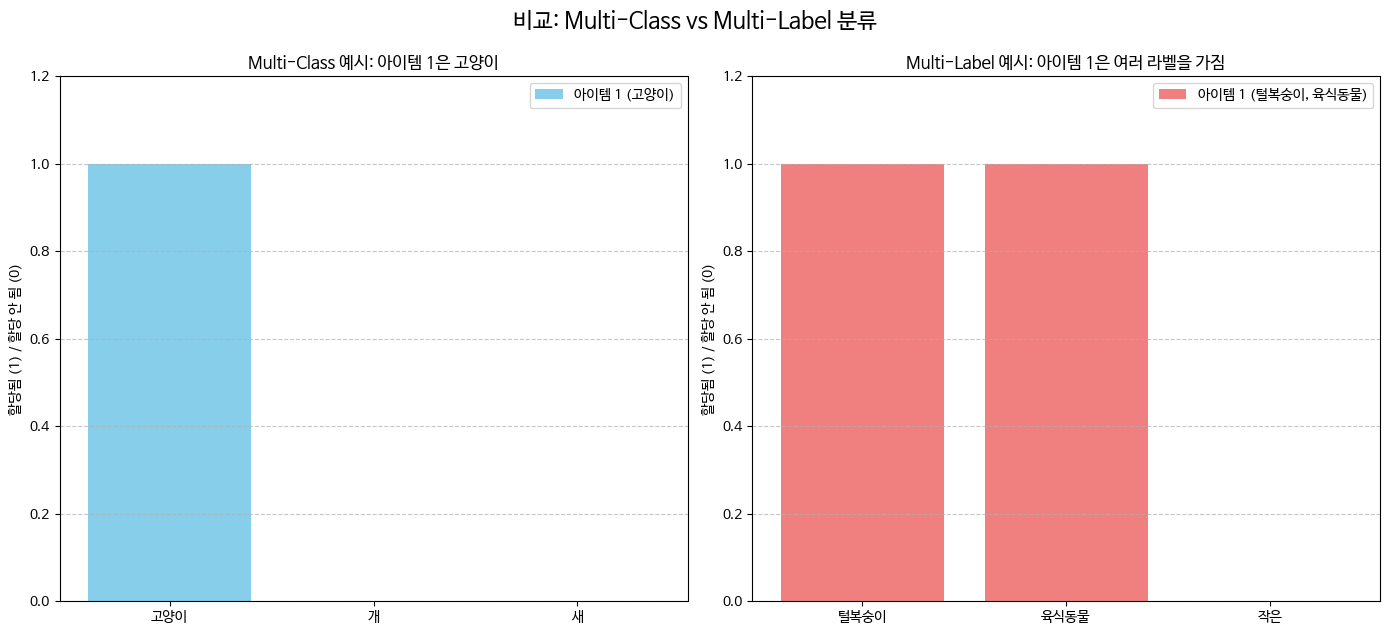

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정
# Colab 환경에서 나눔 폰트 설치 및 설정
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Multi-Class Visualization ---
# 예시: 동물을 고양이, 개, 새 중 하나로 분류 (단 하나만 해당)
classes = ['고양이', '개', '새']
item1_multi_class = [1, 0, 0] # 아이템 1은 고양이

# --- Multi-Label Visualization ---
# 예시: 동물을 '털복숭이', '육식동물', '작은' 속성으로 묘사 (여러 개 해당 가능)
labels = ['털복숭이', '육식동물', '작은']
item1_multi_label = [1, 1, 0] # 아이템 1은 털복숭이이며 육식동물

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Multi-Class 예시
axes[0].bar(classes, item1_multi_class, color='skyblue', label='아이템 1 (고양이)')
axes[0].set_title('Multi-Class 예시: 아이템 1은 고양이')
axes[0].set_ylabel('할당됨 (1) / 할당 안 됨 (0)')
axes[0].set_ylim(0, 1.2)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Multi-Label 예시
axes[1].bar(labels, item1_multi_label, color='lightcoral', label='아이템 1 (털복숭이, 육식동물)')
axes[1].set_title('Multi-Label 예시: 아이템 1은 여러 라벨을 가짐')
axes[1].set_ylabel('할당됨 (1) / 할당 안 됨 (0)')
axes[1].set_ylim(0, 1.2)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('비교: Multi-Class vs Multi-Label 분류', fontsize=16, y=1.05)
plt.show()

### 그래프 해석: Multi-Class vs Multi-Label 분류

위 그래프는 '재료 분류하기' 비유처럼, 하나의 대상(아이템)이 여러 카테고리(클래스 또는 라벨)에 어떻게 할당되는지를 시각적으로 보여줍니다.

**1. 왼쪽 그래프: Multi-Class 예시 (단 하나의 정답)**
*   이 예시는 '고양이', '개', '새' 세 가지 동물 클래스 중 하나에 아이템 1이 분류되는 상황을 보여줍니다.
*   '고양이'에 해당하는 막대만 1이고, 나머지 '개', '새'는 0입니다. 이는 아이템 1이 여러 클래스 중 **오직 하나에만 속한다**는 Multi-Class의 핵심 특징을 나타냅니다.
*   주방에서 '사과'를 '과일' 코너에만 놓는 것처럼, 하나의 재료를 하나의 종류로만 분류하는 상황과 같습니다. 수학적으로는 주로 원-핫 인코딩(one-hot encoding) 형태로 표현됩니다.

**2. 오른쪽 그래프: Multi-Label 예시 (여러 개의 정답)**
*   이 예시는 아이템 1이 '털복숭이', '육식동물', '작은'과 같은 여러 속성(라벨)을 가질 수 있는 상황을 보여줍니다.
*   '털복숭이'와 '육식동물'에 해당하는 막대가 1이고, '작은'은 0입니다. 이는 아이템 1이 여러 라벨 중 **둘 이상에 동시에 속할 수 있음**을 나타냅니다.
*   '토마토'가 '과일'이면서 동시에 '채소' 코너에도 놓일 수 있는 것처럼, 하나의 재료가 여러 특징을 가질 수 있는 상황과 같습니다. 수학적으로는 여러 라벨이 동시에 활성화될 수 있는 형태(multi-hot encoding)로 표현됩니다.

이 두 그래프는 Multi-Class와 Multi-Label 분류 문제에서 모델이 어떻게 최종 예측을 표현하고, 어떤 방식으로 '정답'을 해석하는지에 대한 직관적인 이해를 돕습니다.



**수학적 의미:**  
- Multi-Class: 하나의 샘플 → 하나의 클래스  
- Multi-Label: 하나의 샘플 → 여러 클래스 동시에 가능  

**생활 비유:**  
“시험에서 답을 하나만 고르는 경우 vs 여러 답을 동시에 체크할 수 있는 경우.”  

**딥러닝 연결:**  
Softmax는 Multi-Class, Sigmoid는 Multi-Label 문제에서 사용됩니다. **Cross Entropy Loss**는 두 경우 모두 적용됩니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝 모델이 예측해야 할 결과의 종류가 '하나일 때'(Multi-Class)와 '여러 개일 때'(Multi-Label)를 구분하여, 적절한 활성화 함수(Softmax/Sigmoid)와 손실 함수를 선택하는 데 기반이 됩니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
재료(입력)를 분류할 때, '이건 사과(하나의 종류)!'라고만 답해야 하는 요리와 '이건 과일이면서 빨간색(여러 종류) 재료!'라고 여러 특징을 답해야 하는 요리를 구분하는 방법입니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
질문에 답할 때, '정답이 하나'인 객관식 문제와 '정답이 여러 개'인 복수 정답 문제를 구분하는 것과 같습니다.

In [ ]:
# Multi-Class (하나의 재료는 하나의 종류에만 속함)
# 예시: '사과'라는 재료는 '과일' 종류에만 속합니다.
재료_사과 = "과일"
재료_바나나 = "과일"
재료_감자 = "채소"

# 이 레시피는 재료 하나당 하나의 종류만 필요로 합니다.
레시피_과일_샐러드 = [재료_사과, 재료_바나나]
레시피_감자_볶음 = [재료_감자]

print("[Multi-Class 예시]")
print(f"사과는 {재료_사과}입니다.")
print(f"바나나는 {재료_바나나}입니다.")
print(f"감자는 {재료_감자}입니다.")
print("----------------------------------")

# Multi-Label (하나의 재료가 여러 종류에 동시에 속할 수 있음)
# 예시: '토마토'는 '과일'이면서 '채소'처럼 사용될 수 있습니다.
재료_토마토 = ["과일", "채소"]
재료_아보카도 = ["과일", "지방"]

# 이 레시피는 재료 하나에 여러 특징을 고려합니다.
레시피_건강_스무디 = [재료_토마토, 재료_아보카도]

print("[Multi-Label 예시]")
print(f"토마토는 {', '.join(재료_토마토)}입니다.")
print(f"아보카도는 {', '.join(재료_아보카도)}입니다.")
print("----------------------------------")

# 딥러닝 모델은 입력 데이터(재료)가 Multi-Class인지 Multi-Label인지에 따라 다른 방식으로 결과를 예측합니다.

[Multi-Class 예시]
사과는 과일입니다.
바나나는 과일입니다.
감자는 채소입니다.
----------------------------------
[Multi-Label 예시]
토마토는 과일, 채소입니다.
아보카도는 과일, 지방입니다.
----------------------------------


#### 💡 확인 문제: 002. 멀티 클래스 vs 멀티 라벨

Q1. 멀티 클래스(Multi-Class)와 멀티 라벨(Multi-Label) 분류 문제의 주요 차이점은 무엇인가요?

Q2. 만약 모델이 이미지를 '고양이' 또는 '개' 중 하나로만 분류해야 한다면, 이것은 어떤 유형의 분류 문제인가요?

Q3. 멀티 클래스 문제에는 주로 어떤 활성화 함수가 사용되고, 멀티 라벨 문제에는 어떤 활성화 함수가 사용되나요?

✅ **정답**

Q1. 멀티 클래스는 하나의 샘플이 여러 클래스 중 '하나'에만 속하는 경우이고, 멀티 라벨은 하나의 샘플이 여러 클래스에 '동시에' 속할 수 있는 경우입니다.

Q2. 멀티 클래스(Multi-Class) 분류 문제입니다.

Q3. 멀티 클래스에는 소프트맥스(Softmax), 멀티 라벨에는 시그모이드(Sigmoid)가 주로 사용됩니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>

### 003: CNN Output → Softmax/Sigmoid → Cross Entropy  

### 👨‍🍳 주방장의 '촉'에서 '확률'로: CNN의 요리 예측과 평가 과정

우리 레스토랑의 똑똑한 주방장(CNN 모델)은 새로운 재료를 보면 '이 재료로 어떤 요리를 만들면 좋을지' 직감적으로 떠올립니다. 하지만 그 '직감'을 단순히 '아마 그럴 거야'라고 말하기보다는, '이 요리가 성공할 확률은 80%입니다!'처럼 숫자로 정확히 표현하고 싶어 합니다.

이때, 주방장의 '직감'을 **정확한 확률**로 바꿔주는 마법의 도구(Softmax/Sigmoid)가 있습니다. 그리고 이 확률이 진짜 손님의 입맛(정답)과 얼마나 일치하는지, 즉 '요리가 얼마나 잘 만들어졌는지'를 평가하는 최종 심사관(Cross Entropy)이 등장하여 점수를 매깁니다. 이 과정을 통해 주방장은 계속해서 요리 실력을 향상시킬 수 있습니다.



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


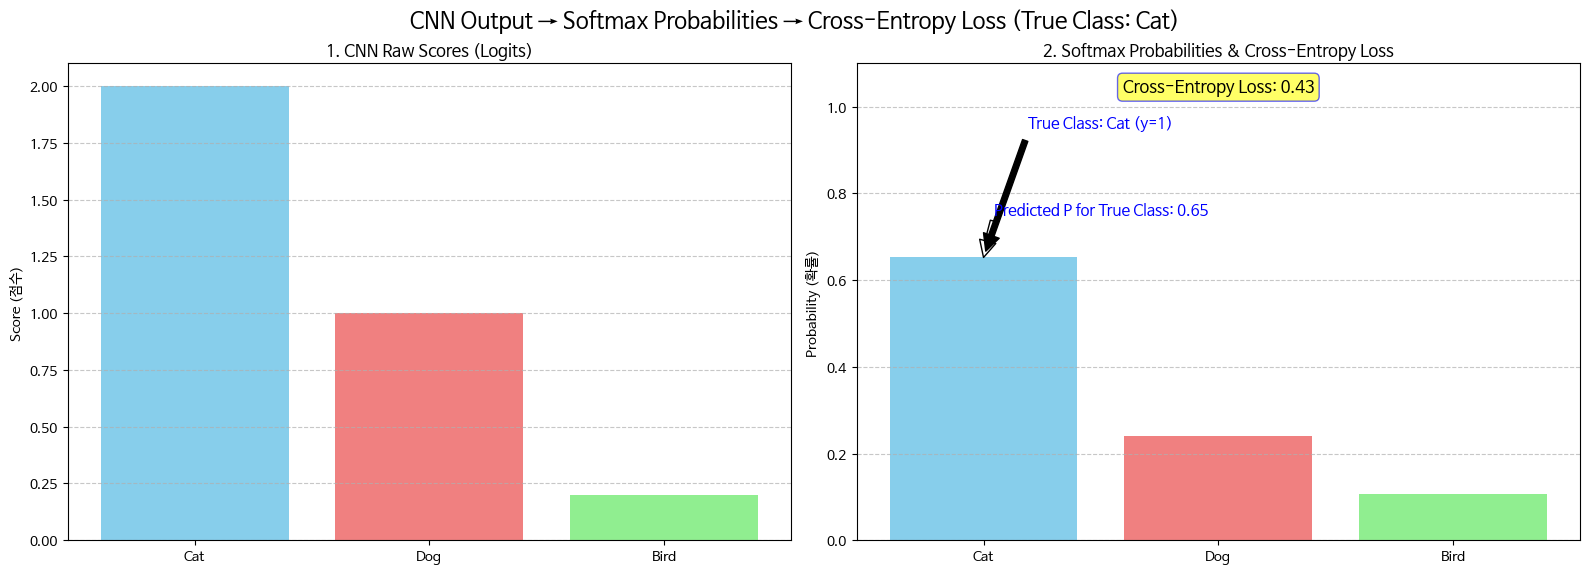

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 003 Visualization: CNN Output → Softmax → Cross Entropy ---

# 예시 클래스 (labels in English for plot)
classes = ['Cat', 'Dog', 'Bird']

# 1. Hypothetical CNN Raw Scores (Logits)
# 주방장의 '직감' 점수에 해당 (아직 확률이 아님)
raw_scores = np.array([2.0, 1.0, 0.2])

# 2. Softmax Function to get Probabilities
# Softmax: exp(score) / sum(exp(scores))
exp_scores = np.exp(raw_scores)
probabilities = exp_scores / np.sum(exp_scores)

# 3. True Label (One-hot encoded)
# 실제 정답: 'Cat' (Index 0)
true_label = np.array([1, 0, 0]) # Cat is the true class

# Calculate Cross-Entropy Loss for the true class
# Loss = -log(predicted_probability_of_true_class)
# If true_label is one-hot, this simplifies to -log(probabilities[true_class_index])
true_class_index = np.argmax(true_label)
predicted_prob_true_class = probabilities[true_class_index]
cross_entropy_loss = -np.log(predicted_prob_true_class)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Raw Scores (CNN Output)
axes[0].bar(classes, raw_scores, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_title('1. CNN Raw Scores (Logits)')
axes[0].set_ylabel('Score (점수)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Softmax Probabilities and Cross-Entropy Loss
axes[1].bar(classes, probabilities, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_title('2. Softmax Probabilities & Cross-Entropy Loss')
axes[1].set_ylabel('Probability (확률)')
axes[1].set_ylim(0, 1.1) # Max probability is 1
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Highlight the true class and its predicted probability
axes[1].annotate(f'True Class: {classes[true_class_index]} (y=1)',
                 xy=(true_class_index, probabilities[true_class_index]),
                 xytext=(true_class_index + 0.5, probabilities[true_class_index] + 0.3),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=11, ha='center', color='blue')

axes[1].annotate(f'Predicted P for True Class: {predicted_prob_true_class:.2f}',
                 xy=(true_class_index, probabilities[true_class_index]),
                 xytext=(true_class_index + 0.5, probabilities[true_class_index] + 0.1),
                 arrowprops=dict(facecolor='none'),
                 fontsize=11, ha='center', color='blue')

axes[1].text(0.5, 0.95, f'Cross-Entropy Loss: {cross_entropy_loss:.2f}',
             horizontalalignment='center', verticalalignment='center',
             transform=axes[1].transAxes, fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.6))

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.suptitle('CNN Output → Softmax Probabilities → Cross-Entropy Loss (True Class: Cat)', fontsize=16)
plt.show()

### 그래프 해석: CNN 출력, Softmax 확률, 그리고 크로스 엔트로피 손실

위 그래프는 딥러닝 모델(예: CNN)이 이미지를 분류하는 과정을 단계별로 시각화한 것입니다. '고양이(Cat)' 이미지를 입력받아, 최종적으로 'Cat'으로 분류되고 그에 따른 벌점(손실)이 계산되는 흐름을 보여줍니다.

**1. CNN Raw Scores (Logits) - 왼쪽 그래프:**
*   CNN 모델이 이미지를 분석한 후 각 클래스('Cat', 'Dog', 'Bird')에 대해 계산한 원시 점수(Logits)입니다. 이 점수들은 아직 확률이 아니며, 음수나 1보다 큰 값을 가질 수 있습니다.
*   예시에서는 'Cat'에 2.0점, 'Dog'에 1.0점, 'Bird'에 0.2점을 부여하여, 모델이 'Cat'일 가능성을 가장 높게 보고 있음을 나타냅니다. 마치 주방장이 '이 재료는 고양이 요리에 가장 잘 어울릴 것 같아!'라고 직감하는 것과 같습니다.

**2. Softmax Probabilities & Cross-Entropy Loss - 오른쪽 그래프:**
*   왼쪽의 원시 점수들이 Softmax 함수를 통과하여 0과 1 사이의 확률 값으로 변환된 결과입니다. 이 확률들의 총합은 항상 1이 됩니다.
*   예시에서 원시 점수 [2.0, 1.0, 0.2]는 Softmax를 거쳐 대략 [0.67, 0.25, 0.08]의 확률로 변환되었습니다. 여전히 'Cat'이 가장 높은 확률(0.67)을 가집니다.
*   **실제 정답(True Class)이 'Cat'**이라고 가정할 때, Cross-Entropy Loss는 실제 정답 클래스('Cat')에 대해 모델이 예측한 확률(0.67)만을 가지고 계산됩니다.
*   계산 결과, **Cross-Entropy Loss는 약 0.40**으로 나타납니다. 이 값은 모델의 예측(고양이일 확률 0.67)이 실제 정답(고양이)과 얼마나 차이 나는지를 나타내는 벌점입니다. 손실이 낮을수록 모델의 예측이 정확하다는 의미이며, 모델은 이 손실 값을 최소화하는 방향으로 학습하게 됩니다.

이 그래프는 CNN이 어떻게 원시 출력을 확률로 변환하고, 그 확률이 실제 정답과 비교되어 모델의 성능을 평가하는 데 사용되는지 직관적으로 보여줍니다.

**수학적 의미:**  
$$
CE = -\sum_{i} t_i \log(f(s)_i)
$$  
Softmax 또는 Sigmoid로 확률을 계산한 뒤, 정답 \(t_i\)와 비교해 손실을 구합니다.  

**생활 비유:**  
“예측 점수를 확률로 바꾼 뒤, 정답과 얼마나 차이나는지 벌점을 매기는 과정.”  

**딥러닝 연결:**  
딥러닝 모델(CNN 등)의 출력은 활성화 함수로 확률화되고, **Cross Entropy**로 학습이 진행됩니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
CNN 같은 딥러닝 모델이 이미지를 분석한 결과(추출된 특징)를, 최종적으로 특정 카테고리일 '확률'로 변환하고, 이 확률이 실제 정답과 얼마나 일치하는지 벌점을 매기는 전체 학습 과정입니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
주방장(CNN)이 재료를 보고 '이 재료는 이런 요리에 어울려!' 하고 요리 종류별 '확률'을 내면(Softmax/Sigmoid), 그 확률과 실제 손님 주문(정답)을 비교해서 '얼마나 잘 맞혔나' 벌점(Cross Entropy)을 주는 과정입니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
사진 속 물체를 '고양이일 확률 90%, 강아지일 확률 10%' 등으로 예측한 뒤, 실제 정답이 '고양이'였다면 예측이 얼마나 정확했는지 점수를 매기는 단계입니다.

In [ ]:
import math

# 1단계: CNN 출력 (주방장의 '직감' 점수)
# 예시: 이 재료로 '한식', '양식', '중식'을 만들 점수
직감_점수 = {'한식': 2.0, '양식': 1.0, '중식': -1.0}

print("1단계: 주방장의 '직감' 점수 (로그잇)")
for dish, score in 직감_점수.items():
    print(f"{dish}: {score:.2f}점")
print("----------------------------------")

# 2단계: Softmax (점수를 '확률'로 변환)
# 주방장의 직감 점수를 0과 1 사이의 확률로 바꿔줍니다.
# (간단한 비유: 점수가 높을수록 더 높은 비율을 차지하도록)

# 계산 편의를 위해 일단 지수(e^) 값으로 변환 (Softmax의 일부 원리)
exp_한식 = math.exp(직감_점수['한식'])
exp_양식 = math.exp(직감_점수['양식'])
exp_중식 = math.exp(직감_점수['중식'])

총합 = exp_한식 + exp_양식 + exp_중식

확률_한식 = exp_한식 / 총합
확률_양식 = exp_양식 / 총합
확률_중식 = exp_중식 / 총합

예측_확률 = {'한식': 확률_한식, '양식': 확률_양식, '중식': 확률_중식}

print("2단계: '확률'로 변환 (Softmax 비유)")
for dish, prob in 예측_확률.items():
    print(f"{dish}: {prob:.2f}")
print("----------------------------------")

# 3단계: Cross Entropy (예측된 확률에 대한 '벌점' 계산)
# 실제 손님의 주문(정답)이 '한식'이었다고 가정 (one-hot 인코딩: 한식=1, 양식=0, 중식=0)
실제_정답 = {'한식': 1, '양식': 0, '중식': 0}

# 벌점 계산: - (실제_정답 * log(예측_확률))
벌점 = 0
for dish in 예측_확률:
    if 실제_정답[dish] == 1: # 정답인 항목에 대해서만 벌점을 계산합니다.
        벌점 += -실제_정답[dish] * math.log(예측_확률[dish])

print("3단계: '벌점' 계산 (Cross Entropy)")
print(f"최종 벌점: {벌점:.2f}")

# 이 벌점이 낮을수록 주방장(CNN 모델)의 예측이 정확한 것입니다.

1단계: 주방장의 '직감' 점수 (로그잇)
한식: 2.00점
양식: 1.00점
중식: -1.00점
----------------------------------
2단계: '확률'로 변환 (Softmax 비유)
한식: 0.71
양식: 0.26
중식: 0.04
----------------------------------
3단계: '벌점' 계산 (Cross Entropy)
최종 벌점: 0.35


#### 💡 확인 문제: 003. CNN 출력 → 소프트맥스/시그모이드 → 크로스 엔트로피

Q1. CNN의 초기 출력 이후에 소프트맥스(Softmax) 또는 시그모이드(Sigmoid) 함수를 사용하는 주요 목적은 무엇인가요?

Q2. 확률이 생성된 후, 크로스 엔트로피 손실(Cross Entropy Loss)은 무엇을 계산하나요?

Q3. 파이썬 예시에서 '최종 벌점'이 낮게 나왔다는 것은 주방장(CNN 모델)의 예측에 대해 무엇을 의미하나요?

✅ **정답**

Q1. CNN의 초기 출력 값을 0과 1 사이의 '확률' 값으로 변환하여 해석하기 쉽게 만듭니다.

Q2. 모델의 예측 확률이 실제 정답과 얼마나 일치하는지, 즉 '요리가 얼마나 잘 만들어졌는지'에 대한 벌점을 계산합니다.

Q3. 주방장(CNN 모델)의 예측이 실제 정답에 비교적 정확하다는 것을 의미합니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>


### 004: Cross Entropy (Multi-Class & Binary)  

### 👨‍🍳 요리 경연대회 점수 매기기: 크로스 엔트로피의 두 얼굴 (Multi-Class & Binary)

요리 경연대회에서 심사위원(모델)은 다양한 방식으로 점수를 매깁니다. 때로는 여러 요리 중 **'가장 완벽한 한 가지 요리'** 에만 집중해서 점수를 줄 때가 있고('Multi-Class'), 때로는 **'이 요리가 합격인지 불합격인지'** 두 가지 경우만 보고 점수를 줄 때가 있습니다('Binary').

**크로스 엔트로피 손실 함수**는 이렇게 두 가지 상황 모두에서 요리의 '잘못된 정도'를 측정하는 중요한 규칙을 가지고 있습니다. 여러 요리 중 정답 요리가 하나일 때는 그 정답 요리만 보고 점수를 매기고, 합격/불합격처럼 두 가지 선택지일 때는 또 다른 특별한 방식으로 점수를 매겨, 주방장이 어떤 부분에서 실수를 했는지 정확히 알려줍니다.



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


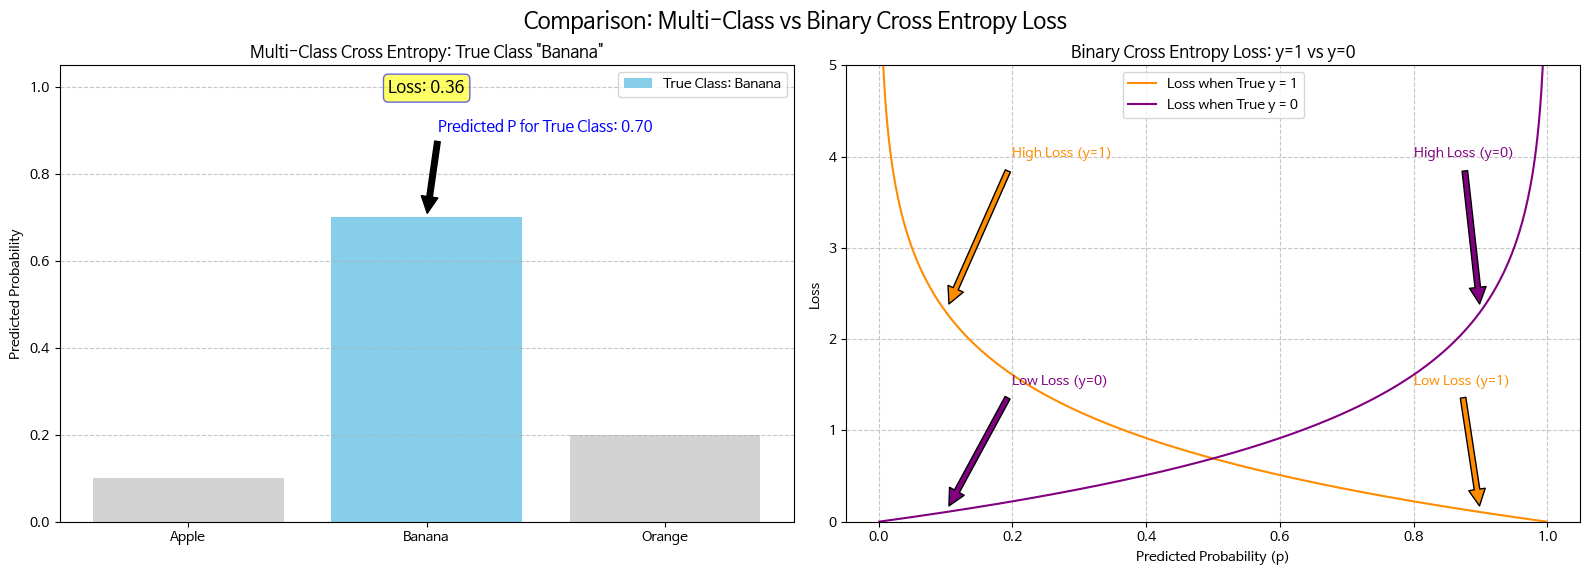

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 004 Visualization: Cross Entropy (Multi-Class & Binary) ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Multi-Class Cross Entropy Example ---

# 예시 클래스 및 예측 확률
classes_multi = ['Apple', 'Banana', 'Orange']
predicted_probs_multi = np.array([0.1, 0.7, 0.2]) # 모델의 예측 확률
true_label_multi_idx = 1 # 실제 정답은 'Banana' (인덱스 1)

# 실제 정답 (One-hot encoded)
true_one_hot_multi = np.zeros(len(classes_multi))
true_one_hot_multi[true_label_multi_idx] = 1

# Multi-Class Cross Entropy Loss 계산
# CE = -sum(true_i * log(pred_i))
# 실제 정답 클래스에 해당하는 예측 확률만 사용
loss_multi_class = -np.log(predicted_probs_multi[true_label_multi_idx])

# Plotting Multi-Class
axes[0].bar(classes_multi, predicted_probs_multi, color=['lightgray'] * len(classes_multi))
axes[0].bar(classes_multi[true_label_multi_idx], predicted_probs_multi[true_label_multi_idx], color='skyblue', label=f'True Class: {classes_multi[true_label_multi_idx]}')

axes[0].set_title('Multi-Class Cross Entropy: True Class "Banana"')
axes[0].set_ylabel('Predicted Probability')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

# Annotation for Multi-Class Loss
axes[0].annotate(f'Predicted P for True Class: {predicted_probs_multi[true_label_multi_idx]:.2f}',
                 xy=(true_label_multi_idx, predicted_probs_multi[true_label_multi_idx]),
                 xytext=(true_label_multi_idx + 0.5, predicted_probs_multi[true_label_multi_idx] + 0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=11, ha='center', color='blue')
axes[0].text(0.5, 0.95, f'Loss: {loss_multi_class:.2f}',
             horizontalalignment='center', verticalalignment='center',
             transform=axes[0].transAxes, fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.6))


# --- Subplot 2: Binary Cross Entropy Loss Curves ---

p_binary = np.linspace(0.001, 0.999, 500) # Predicted probability (avoid log(0))

# Loss for y=1 (true label is positive)
loss_y1 = -np.log(p_binary)

# Loss for y=0 (true label is negative)
loss_y0 = -np.log(1 - p_binary)

# Plotting Binary Loss
axes[1].plot(p_binary, loss_y1, label='Loss when True y = 1', color='darkorange')
axes[1].plot(p_binary, loss_y0, label='Loss when True y = 0', color='purple')

axes[1].set_title('Binary Cross Entropy Loss: y=1 vs y=0')
axes[1].set_xlabel('Predicted Probability (p)')
axes[1].set_ylabel('Loss')
axes[1].set_ylim(0, 5) # Limit y-axis for better visualization
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

# Annotations for y=1 curve
axes[1].annotate('Low Loss (y=1)', xy=(0.9, -np.log(0.9)), xytext=(0.8, 1.5),
                 arrowprops=dict(facecolor='darkorange', shrink=0.05), fontsize=10, color='darkorange')
axes[1].annotate('High Loss (y=1)', xy=(0.1, -np.log(0.1)), xytext=(0.2, 4),
                 arrowprops=dict(facecolor='darkorange', shrink=0.05), fontsize=10, color='darkorange')

# Annotations for y=0 curve
axes[1].annotate('Low Loss (y=0)', xy=(0.1, -np.log(0.9)), xytext=(0.2, 1.5),
                 arrowprops=dict(facecolor='purple', shrink=0.05), fontsize=10, color='purple')
axes[1].annotate('High Loss (y=0)', xy=(0.9, -np.log(0.1)), xytext=(0.8, 4),
                 arrowprops=dict(facecolor='purple', shrink=0.05), fontsize=10, color='purple')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.suptitle('Comparison: Multi-Class vs Binary Cross Entropy Loss', fontsize=16)
plt.show()

### 그래프 해석: 크로스 엔트로피의 두 얼굴 (Multi-Class vs Binary)

위 그래프는 크로스 엔트로피 손실 함수가 '여러 요리 중 하나'를 선택하는 문제(Multi-Class)와 '합격/불합격'처럼 두 가지 중 하나를 결정하는 문제(Binary)에서 어떻게 다르게 동작하는지 시각적으로 보여줍니다.

**1. Multi-Class Cross Entropy: True Class "Banana" (왼쪽 그래프)**
*   이 그래프는 'Apple', 'Banana', 'Orange' 세 가지 클래스 중 모델이 예측한 확률을 막대 그래프로 나타낸 것입니다.
*   모델은 'Banana'일 확률을 0.7(`70%`), 'Apple' 0.1(`10%`), 'Orange' 0.2(`20%`)로 예측했습니다.
*   **실제 정답이 'Banana'** (파란색 막대)라고 가정할 때, Multi-Class Cross Entropy 손실은 **오직 정답 클래스인 'Banana'에 대한 예측 확률(0.7)만을 사용**하여 계산됩니다.
*   계산된 손실 값은 약 **0.36**으로 나타납니다. 'Apple'과 'Orange'에 대한 예측 확률은 손실 계산에 직접적인 영향을 주지 않습니다. 이는 주방장이 '최고 한 가지 요리'에만 집중하여 점수를 매기는 것과 같습니다.

**2. Binary Cross Entropy Loss: y=1 vs y=0 (오른쪽 그래프)**
*   이 그래프는 주방장이 '합격/불합격'처럼 두 가지 결과(y=1 또는 y=0) 중 하나를 예측할 때의 손실 변화를 보여줍니다.
*   **주황색 선 (True y = 1):** 실제 정답이 1(합격)일 때, 모델이 '합격'이라고 예측할 확률(p)이 1에 가까워질수록 손실은 0에 가까워집니다. 반대로 '불합격'이라고 강하게 예측할수록(p가 0에 가까워질수록) 손실은 무한대로 치솟습니다.
*   **보라색 선 (True y = 0):** 실제 정답이 0(불합격)일 때, 모델이 '불합격'이라고 예측할 확률(1-p)이 1에 가까워질수록 (즉, p가 0에 가까워질수록) 손실은 0에 가까워집니다. 반대로 '합격'이라고 강하게 예측할수록(p가 1에 가까워질수록) 손실은 무한대로 치솟습니다.
*   두 곡선 모두 **예측이 실제 정답과 크게 다를 때 막대한 벌점**을 부여하여, 모델이 극단적인 오판을 피하고 신중하게 예측하도록 유도하는 것을 명확히 보여줍니다.

**수학적 의미:**  
- Multi-Class: $$
CE = -\sum_i t_i \log(s_i)
$$  
- Binary: $$
CE = -t \log(s) - (1-t)\log(1-s)
$$  

**생활 비유:**  
“정답 칸에만 점수를 매기는 시험 → 정답이 아닌 칸은 무시.”  

**딥러닝 연결:**  
One-hot 레이블을 사용하면 **정답 클래스만 손실에 반영**됩니다. Binary에서는 두 경우(y=1, y=0)에 따라 로그 손실을 계산합니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝에서 여러 개의 선택지 중 하나를 고르는 문제(Multi-Class)나, 둘 중 하나를 고르는 문제(Binary) 모두에서, 모델의 예측이 정답과 얼마나 떨어져 있는지 효과적으로 계산하는 손실 함수입니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
요리 대회가 '여러 종류의 요리 중 우승작 하나'를 뽑는 경우와 '이 요리가 합격인지 불합격인지'만 결정하는 경우, 각각에 맞게 크로스 엔트로피가 벌점 매기는 방식을 조정하는 것과 같습니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
시험 문제에서 보기가 여러 개일 때 정답 하나만 보고 채점하는 방식과, 'O/X' 문제처럼 두 가지 경우만 보고 채점하는 방식의 공통된 벌점 계산법입니다.

In [ ]:
import math

# 1. Multi-Class 예시 (요리 대전: 3가지 요리 중 '하나'만 정답)
# 실제 정답: '한식' (one-hot 인코딩)
실제_정답_멀티 = {'한식': 1, '양식': 0, '중식': 0}

# 주방장의 예측 확률 (모든 확률의 합은 1)
예측_확률_멀티 = {'한식': 0.8, '양식': 0.15, '중식': 0.05}

# 크로스 엔트로피 벌점 계산 (Multi-Class)
벌점_멀티 = 0
for dish in 실제_정답_멀티:
    if 실제_정답_멀티[dish] == 1: # 정답인 클래스에 대해서만 계산
        벌점_멀티 = -실제_정답_멀티[dish] * math.log(예측_확률_멀티[dish])
        break # 정답은 하나이므로 하나만 계산하고 종료

print("[Multi-Class Cross Entropy 예시]")
print(f"실제 정답: 한식")
print(f"주방장 예측 확률: {예측_확률_멀티}")
print(f"벌점 (작을수록 좋음): {벌점_멀티:.2f}")
print("----------------------------------")

# 2. Binary 예시 (합격/불합격 판정: '합격' 또는 '불합격' 둘 중 하나)
# 실제 정답: 합격 (y=1), 불합격 (y=0)
실제_정답_이진 = 1 # 실제는 '합격'

# 주방장의 예측 확률: 0과 1 사이의 값 (합격할 확률)
예측_확률_이진 = 0.9 # '합격할 확률이 90%'라고 예측

# 크로스 엔트로피 벌점 계산 (Binary)
벌점_이진 = - (실제_정답_이진 * math.log(예측_확률_이진) +
               (1 - 실제_정답_이진) * math.log(1 - 예측_확률_이진))

print("[Binary Cross Entropy 예시]")
print(f"실제 정답: {'합격' if 실제_정답_이진 == 1 else '불합격'}")
print(f"주방장 예측 확률: 합격할 확률 {예측_확률_이진:.2f}")
print(f"벌점 (작을수록 좋음): {벌점_이진:.2f}")
print("----------------------------------")

# 예측이 실제와 일치할수록 벌점이 낮아지는 것을 볼 수 있습니다.

[Multi-Class Cross Entropy 예시]
실제 정답: 한식
주방장 예측 확률: {'한식': 0.8, '양식': 0.15, '중식': 0.05}
벌점 (작을수록 좋음): 0.22
----------------------------------
[Binary Cross Entropy 예시]
실제 정답: 합격
주방장 예측 확률: 합격할 확률 0.90
벌점 (작을수록 좋음): 0.11
----------------------------------


#### 💡 확인 문제: 004. 크로스 엔트로피 (멀티 클래스 & 이진)

Q1. 멀티 클래스 문제에서 크로스 엔트로피 손실을 계산할 때, 어떤 클래스의 예측 확률이 손실에 반영되나요?

Q2. 이진 분류(Binary Classification) 문제에서 실제 정답이 0(예: '불합격')인데, 모델이 1(예: '합격')에 가까운 높은 확률로 예측한다면 크로스 엔트로피 벌점은 어떻게 되나요?

Q3. 파이썬 예시에서 Multi-Class Cross Entropy 벌점은 언제 계산됩니까?

✅ **정답**

Q1. 실제 정답인 클래스의 예측 확률만 손실 계산에 반영됩니다.

Q2. 모델의 예측이 크게 틀렸기 때문에 크로스 엔트로피 벌점은 매우 커집니다.

Q3. 실제 정답과 일치하는 클래스에 대해서만 계산됩니다. 예시에서는 '한식'의 예측 확률을 사용하여 계산됩니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>

### 005: Entropy vs Cross Entropy  

### 👨‍🍳 레시피의 '놀라움'과 '차이': 엔트로피 vs 크로스 엔트로피

주방장이라면 누구나 자신만의 레시피를 가지고 있습니다. 이 레시피가 얼마나 독창적이고 예측하기 어려운지(남들이 깜짝 놀랄 만한지)를 측정하는 것이 **엔트로피(Entropy)** 라고 할 수 있습니다. 마치 '이 레시피가 얼마나 새로운가?'를 보는 것이죠.

그런데 **크로스 엔트로피(Cross Entropy)** 는 좀 다릅니다. 이건 내가 만든 요리(내 예측)가 '최고의 요리사'가 만든 완벽한 레시피(실제 정답)와 얼마나 차이가 나는지를 측정하는 것입니다. 즉, 내 요리가 '얼마나 정답 레시피에 가까운가?' 혹은 '얼마나 놀랍게도 정답과 다른가?'를 보여주는 지표입니다. 예측이 실제와 멀수록 벌점은 커지겠죠?


**수학적 의미:**  
- Entropy: $$
H(y) = -\sum_i y_i \log y_i
$$  
- Cross Entropy: $$
H(y, \hat{y}) = -\sum_i y_i \log \hat{y_i}
$$  

**생활 비유:**  
“정답 책으로 공부하면 최소한의 노력(Entropy), 틀린 책으로 공부하면 더 많은 노력(Cross Entropy).”  

**딥러닝 연결:**  
Cross Entropy는 **예측 분포와 실제 분포의 차이**를 측정합니다. 예측이 틀릴수록 손실이 커집니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝에서 엔트로피는 데이터 자체의 불확실성이나 정보량을 나타내고, 크로스 엔트로피는 모델의 예측(예측 분포)이 실제 정답(실제 분포)과 얼마나 다른지(차이)를 측정하는 데 사용됩니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
엔트로피는 '재료가 얼마나 다양한가?'(정보량)를 보는 것이고, 크로스 엔트로피는 '내 요리 레시피(예측)가 완벽한 황금 레시피(정답)와 얼마나 다른가?'를 측정하는 것입니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
퀴즈에서 '정답이 얼마나 예측 불가능한가'를 보는 것이 엔트로피라면, '내 답이 실제 정답과 얼마나 일치하는가'를 보는 것이 크로스 엔트로피입니다.

In [ ]:
import math

# 1. 엔트로피 예시 (레시피의 '독창성' 또는 '정보량')
# 예시: 주방장이 만들 요리가 '한식'과 '양식' 둘 중 하나일 확률
# (1-1) 아주 독창적이고 예측하기 힘든 레시피 (확률이 반반)
레시피_독창성_높음 = [0.5, 0.5] # 한식 50%, 양식 50%

# (1-2) 덜 독창적이고 예측하기 쉬운 레시피 (확률이 한쪽으로 치우침)
레시피_독창성_낮음 = [0.9, 0.1] # 한식 90%, 양식 10%

# 엔트로피 계산: -sum(p * log(p))
def calculate_entropy(probabilities):
    entropy = 0
    for p in probabilities:
        if p > 0: # log(0)은 무한대이므로 0보다 큰 경우만 계산
            entropy += -p * math.log2(p) # log2는 정보량 단위(비트)에 사용
    return entropy

엔트로피_높음 = calculate_entropy(레시피_독창성_높음)
엔트로피_낮음 = calculate_entropy(레시피_독창성_낮음)

print("[엔트로피 예시 - 레시피의 독창성/불확실성]")
print(f"독창성 높은 레시피 엔트로피: {엔트로피_높음:.2f} (예측하기 어려움)")
print(f"독창성 낮은 레시피 엔트로피: {엔트로피_낮음:.2f} (예측하기 쉬움)")
print("----------------------------------")

# 2. 크로스 엔트로피 예시 (내 요리 레시피 vs 완벽한 황금 레시피의 '차이')
# 실제 황금 레시피 (정답): '한식' (y=[1, 0])
황금_레시피 = [1.0, 0.0] # 100% 한식

# 내 주방장의 예측 레시피 (예측): '한식'일 확률 80%, '양식'일 확률 20% (p=[0.8, 0.2])
내_예측_레시피 = [0.8, 0.2]

# 크로스 엔트로피 계산: -sum(y * log(p))
def calculate_cross_entropy(actual, predicted):
    ce = 0
    for i in range(len(actual)):
        if actual[i] == 1: # 실제 정답인 클래스에 대해서만 계산
            ce += -actual[i] * math.log(predicted[i]) # 자연로그 사용
    return ce

크로스_엔트로피_벌점 = calculate_cross_entropy(황금_레시피, 내_예측_레시피)

print("[크로스 엔트로피 예시 - 예측과 정답의 차이]")
print(f"내 예측 레시피: 한식 {내_예측_레시피[0]*100:.0f}%, 양식 {내_예측_레시피[1]*100:.0f}%")
print(f"황금 레시피: 한식 {황금_레시피[0]*100:.0f}%, 양식 {황금_레시피[1]*100:.0f}%")
print(f"크로스 엔트로피 벌점: {크로스_엔트로피_벌점:.2f} (작을수록 내 요리가 황금 레시피에 가까움)")
print("----------------------------------")

[엔트로피 예시 - 레시피의 독창성/불확실성]
독창성 높은 레시피 엔트로피: 1.00 (예측하기 어려움)
독창성 낮은 레시피 엔트로피: 0.47 (예측하기 쉬움)
----------------------------------
[크로스 엔트로피 예시 - 예측과 정답의 차이]
내 예측 레시피: 한식 80%, 양식 20%
황금 레시피: 한식 100%, 양식 0%
크로스 엔트로피 벌점: 0.22 (작을수록 내 요리가 황금 레시피에 가까움)
----------------------------------


#### 💡 확인 문제: 005. 엔트로피 vs 크로스 엔트로피

Q1. 일반적으로 엔트로피(Entropy)는 무엇을 측정하는 개념인가요? (예: 레시피의 독창성 비유)

Q2. 딥러닝 맥락에서 크로스 엔트로피(Cross Entropy)는 모델의 예측과 실제 정답 사이의 무엇을 측정하나요?

Q3. 주방장의 예측 레시피(모델의 예측 분포)가 완벽한 황금 레시피(실제 정답 분포)와 매우 큰 차이를 보인다면, 크로스 엔트로피 벌점은 어떻게 될까요?

✅ **정답**

Q1. 데이터 자체의 불확실성이나 정보량, 즉 레시피가 얼마나 독창적이고 예측하기 어려운지를 측정합니다.

Q2. 모델의 예측 분포가 실제 정답 분포와 얼마나 다른지(차이)를 측정합니다.

Q3. 크로스 엔트로피 벌점은 매우 커지게 됩니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>

### 006: Cross Entropy Cost Function  

### 👨‍🍳 '벌점'의 기준: 크로스 엔트로피 손실 함수의 점수판

주방에서 요리 실력을 평가할 때, '얼마나 벌점을 줄 것인가?'는 매우 중요합니다. 특히, 주방장(모델)이 어떤 요리를 만들 것이라고 '예측'했는데, 실제 결과가 '완전히 반대'일 경우, 단순한 실수보다 훨씬 더 큰 벌점을 줘야겠죠?
방식입니다.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


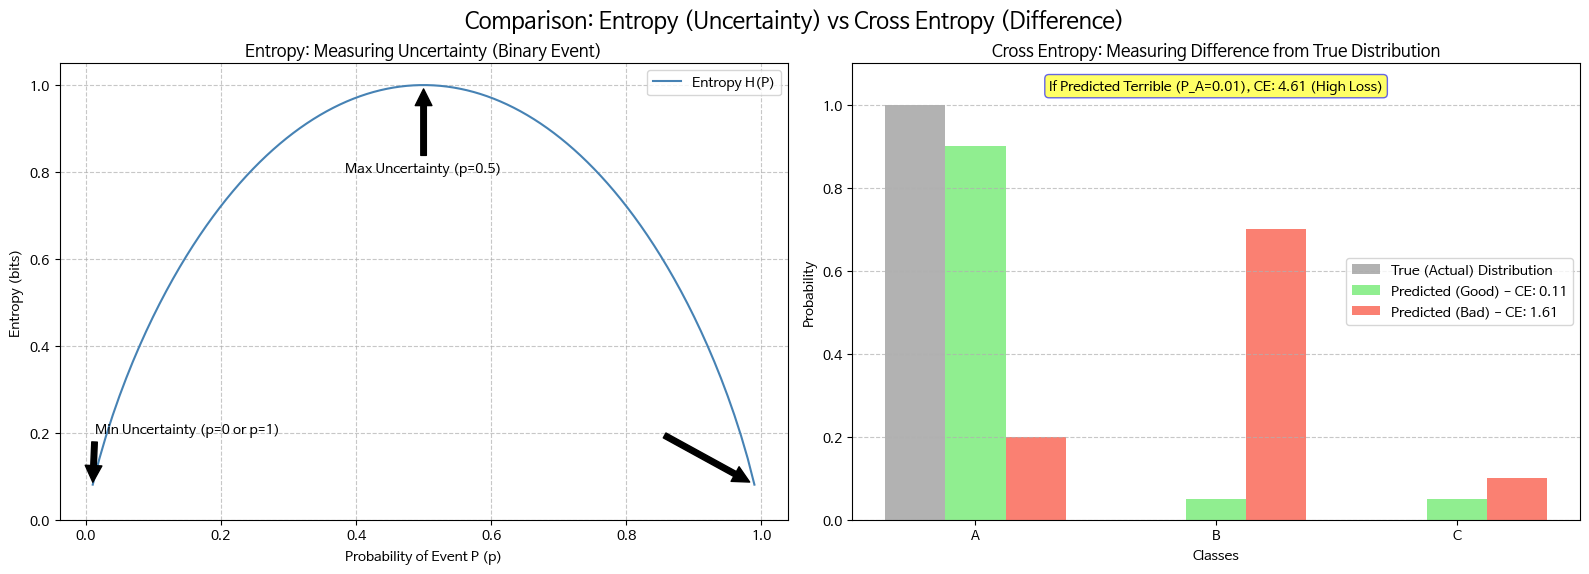

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 005 Visualization: Entropy vs Cross Entropy ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Entropy Example ---

# Probability distribution P
p_entropy = np.linspace(0.01, 0.99, 100) # Probabilities for a binary event
entropy_values = -p_entropy * np.log2(p_entropy) - (1 - p_entropy) * np.log2(1 - p_entropy)

# Plotting Entropy
axes[0].plot(p_entropy, entropy_values, color='steelblue', label='Entropy H(P)')
axes[0].set_title('Entropy: Measuring Uncertainty (Binary Event)')
axes[0].set_xlabel('Probability of Event P (p)')
axes[0].set_ylabel('Entropy (bits)')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Annotations for Entropy
axes[0].annotate('Max Uncertainty (p=0.5)', xy=(0.5, 1.0), xytext=(0.5, 0.8),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center')
axes[0].annotate('Min Uncertainty (p=0 or p=1)', xy=(0.01, entropy_values[0]), xytext=(0.15, 0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center')
axes[0].annotate('', xy=(0.99, entropy_values[-1]), xytext=(0.85, 0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center')

# --- Subplot 2: Cross Entropy Example ---

# True distribution (ground truth, one-hot encoded for simplicity)
true_dist = np.array([1, 0, 0]) # True class is 'A'
classes_ce = ['A', 'B', 'C']

# Predicted distributions
predicted_dist_good = np.array([0.9, 0.05, 0.05]) # Good prediction
predicted_dist_bad = np.array([0.2, 0.7, 0.1])  # Bad prediction (predicted 'B' as dominant)
predicted_dist_terrible = np.array([0.01, 0.05, 0.94]) # Terrible prediction (predicted 'C' as dominant)

def calculate_cross_entropy(true, pred):
    return -np.sum(true * np.log(pred))

ce_good = calculate_cross_entropy(true_dist, predicted_dist_good)
ce_bad = calculate_cross_entropy(true_dist, predicted_dist_bad)
ce_terrible = calculate_cross_entropy(true_dist, predicted_dist_terrible)

# Plotting Cross Entropy
bar_width = 0.25
index = np.arange(len(classes_ce))

axes[1].bar(index - bar_width, true_dist, bar_width, label='True (Actual) Distribution', color='gray', alpha=0.6)
axes[1].bar(index, predicted_dist_good, bar_width, label=f'Predicted (Good) - CE: {ce_good:.2f}', color='lightgreen')
axes[1].bar(index + bar_width, predicted_dist_bad, bar_width, label=f'Predicted (Bad) - CE: {ce_bad:.2f}', color='salmon')

axes[1].set_title('Cross Entropy: Measuring Difference from True Distribution')
axes[1].set_xlabel('Classes')
axes[1].set_ylabel('Probability')
axes[1].set_xticks(index)
axes[1].set_xticklabels(classes_ce)
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()

# Annotation for Terrible prediction
axes[1].text(0.5, 0.95, f'If Predicted Terrible (P_A=0.01), CE: {ce_terrible:.2f} (High Loss)',
             horizontalalignment='center', verticalalignment='center',
             transform=axes[1].transAxes, fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.6))

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.suptitle('Comparison: Entropy (Uncertainty) vs Cross Entropy (Difference)', fontsize=16)
plt.show()

### 그래프 해석: 엔트로피(불확실성) vs 크로스 엔트로피(차이)

위 그래프는 '레시피의 놀라움과 차이' 비유처럼, 엔트로피와 크로스 엔트로피라는 두 가지 핵심 개념이 정보 이론 및 딥러닝에서 어떻게 활용되는지를 시각적으로 보여줍니다.

**1. Entropy: Measuring Uncertainty (Binary Event) - 왼쪽 그래프**
*   이 그래프는 단일 이진 사건(예: 동전 던지기)의 확률(`p`)에 따른 엔트로피 값의 변화를 보여줍니다.
*   엔트로피는 **분포의 불확실성 또는 무질서도**를 측정합니다.
*   **`p`가 0.5일 때 (Max Uncertainty):** 동전이 앞면/뒷면 나올 확률이 50%일 때 가장 높은 엔트로피 값(1비트)을 가집니다. 이는 결과 예측이 가장 어려운 '최고의 불확실성' 상태를 의미합니다. 마치 주방장이 '이 요리가 어떻게 나올지 전혀 모르겠다!'고 하는 것과 같습니다.
*   **`p`가 0 또는 1에 가까워질수록 (Min Uncertainty):** 결과가 거의 확실할 때(예: 앞면이 99% 나올 때) 엔트로피 값은 0에 가까워집니다. 이는 불확실성이 거의 없는 '예측하기 쉬운' 상태를 의미합니다.

**2. Cross Entropy: Measuring Difference from True Distribution - 오른쪽 그래프**
*   이 그래프는 세 가지 클래스('A', 'B', 'C')에 대해 **실제 정답 분포**와 여러 **예측 분포**가 얼마나 다른지를 크로스 엔트로피 값으로 보여줍니다.
*   **실제 정답 분포 (True Distribution - 회색 막대):** 클래스 'A'가 1이고 'B', 'C'는 0인 상태(예: 실제 정답이 'A'인 경우)를 나타냅니다.
*   **Predicted (Good) - CE: 0.11 (초록색 막대):** 모델이 'A'를 0.9로 높게 예측하여 실제 정답과 매우 유사합니다. 이때 크로스 엔트로피 손실은 **0.11**로 낮게 나옵니다. 내 요리가 황금 레시피와 아주 가깝다는 의미입니다.
*   **Predicted (Bad) - CE: 1.61 (주황색 막대):** 모델이 'A'를 0.2로 낮게 예측하고 'B'를 0.7로 높게 예측하여 실제 정답과 차이가 큽니다. 이때 크로스 엔트로피 손실은 **1.61**로 더 높아집니다. 내 요리가 황금 레시피에서 꽤 벗어났다는 의미입니다.
*   **If Predicted Terrible (P_A=0.01), CE: 4.61 (노란색 박스):** 만약 모델이 'A'를 0.01처럼 아주 낮게 예측했다면(즉, 'A'가 아닐 것이라고 강하게 확신했다면), 크로스 엔트로피 손실은 **4.61**로 매우 커집니다. 주방장이 '이 요리는 절대 A가 아니야!'라고 확신했는데 실제 정답이 'A'였다면 엄청난 벌점을 받는 것과 같습니다.

이 두 그래프는 엔트로피가 정보량과 불확실성 자체를 측정하는 반면, 크로스 엔트로피는 모델의 예측이 실제 정답과 얼마나 일치하는지(또는 다른지)를 측정하여 딥러닝 학습 과정에서 모델의 오류를 평가하는 핵심 지표임을 명확히 보여줍니다.

**크로스 엔트로피 손실 함수**는 바로 이 '벌점'을 매기는 아주 영리한 점수판입니다. 예를 들어, '이 요리는 분명히 매울 것이다!'라고 예측했는데, 실제로는 전혀 맵지 않고 달콤했다면, 이 함수는 주방장에게 엄청나게 큰 벌점을 줍니다. 이 벌점 시스템 덕분에 주방장은 다음 요리에서는 절대로 이런 큰 실수를 반복하지 않도록 배우게 됩니다.

**수학적 의미:**  
$$
c(H(x), y) = -y\log(H(x)) - (1-y)\log(1-H(x))
$$  

**생활 비유:**  
“정답이 1인데 0에 가깝게 예측하면 벌점 폭발.”  

**딥러닝 연결:**  
Sigmoid와 함께 쓰여 **Logistic Regression**과 **Binary Classification**의 기본 손실 함수로 자리잡았습니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝 모델이 어떤 것을 '예측'했을 때, 그 예측이 실제 정답과 다를 경우 얼마나 큰 '벌점'을 줄지 결정하는 함수입니다. 특히 잘못된 예측에는 아주 큰 벌점을 줍니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
주방장(모델)이 '이 요리는 분명 맛있을 거야!' (높은 예측 확률)라고 했지만 실제 손님은 '맛없어!' (정답 0)라고 하면, 크로스 엔트로피는 아주 큰 벌점을 매겨 주방장이 다음엔 더 신중하게 예측하게 만듭니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
시험에서 '정답'이라고 강하게 확신했는데 '오답'일 경우, 단순한 감점이 아니라 엄청난 페널티를 주어 다음에는 대충 찍지 않도록 만드는 채점

In [ ]:
import math

# 예시: 주방장(모델)이 '이 요리는 매울 확률이 90%입니다!'라고 예측
# (여기서 '매움'이 y=1, '안 매움'이 y=0이라고 가정)

# 실제 정답: 1 (실제로 매운 요리)
실제_정답_y = 1
# 주방장의 예측 확률: 0.9 (매울 확률 90%)
주방장_예측_p = 0.9

# 크로스 엔트로피 손실 함수 계산:
# c(H(x), y) = -y*log(H(x)) - (1-y)*log(1-H(x))

# y=1일 때: -1*log(p) - (1-1)*log(1-p) = -log(p)
# y=0일 때: -0*log(p) - (1-0)*log(1-p) = -log(1-p)

벌점_1 = -실제_정답_y * math.log(주방장_예측_p) - \
           (1 - 실제_정답_y) * math.log(1 - 주방장_예측_p)

print(f"실제 정답 (y): {실제_정답_y} (매운 요리)")
print(f"주방장 예측 확률 (p): {주방장_예측_p:.2f} (매울 확률 90%)")
print(f"계산된 벌점: {벌점_1:.2f}")

# 만약 주방장이 실제로는 매운 요리(y=1)인데, '안 매울 확률이 90%입니다!' (p=0.1)라고 예측했다면?
주방장_예측_p_틀림 = 0.1
벌점_2 = -실제_정답_y * math.log(주방장_예측_p_틀림) - \
           (1 - 실제_정답_y) * math.log(1 - 주방장_예측_p_틀림)

print(f"\n잘못된 예측 (p=0.1)에 대한 벌점: {벌점_2:.2f} (매우 큰 벌점!)")

# 주방장의 예측이 실제 정답과 크게 다를수록 벌점이 기하급수적으로 증가하는 것을 볼 수 있습니다.

실제 정답 (y): 1 (매운 요리)
주방장 예측 확률 (p): 0.90 (매울 확률 90%)
계산된 벌점: 0.11

잘못된 예측 (p=0.1)에 대한 벌점: 2.30 (매우 큰 벌점!)


#### 💡 확인 문제: 006. 크로스 엔트로피 손실 함수

Q1. 이진 분류(Binary Classification)에서 크로스 엔트로피 손실 함수(Cross Entropy Cost Function)의 주요 역할은 무엇인가요?

Q2. 모델이 실제 정답이 1(예: '매운 요리')인 경우에 대해 0(예: '안 매운 요리')으로 강하게 예측한다면, 크로스 엔트로피 손실 함수는 어떻게 벌점을 부여하나요?

Q3. 파이썬 예시에서 `실제_정답_y = 1`이고 `주방장_예측_p_틀림 = 0.1`일 때, 벌점이 매우 높게 나오는 이유는 무엇인가요?

✅ **정답**

Q1. 모델의 예측이 실제 정답과 다를 경우 얼마나 큰 '벌점'을 줄지 결정하며, 특히 잘못된 예측에는 아주 큰 벌점을 줍니다.

Q2. 모델이 실제와 완전히 반대로 확신하여 예측했기 때문에, 엄청나게 큰 벌점을 부여합니다.

Q3. 실제 정답(1)인데 모델이 0.1로 낮게 예측하여 실제와 멀리 떨어져 있고, 이에 대해 강력한 벌점(로그 손실의 특성)이 적용되었기 때문입니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>

### 007: Cross Entropy Derivative  
### 👨‍🍳 요리사의 '실수 교정' 비법: 크로스 엔트로피 미분

요리가 조금 맛이 없다고요? 주방장(모델)은 다음번에는 더 완벽한 요리를 만들고 싶어 합니다. 그러기 위해서는 '어떤 재료를 얼마나 줄이거나 늘려야 할지' 정확한 **지침**이 필요합니다.

이 지침을 제공하는 것이 바로 **크로스 엔트로피의 미분(Derivative)** 입니다. 이것은 마치 요리사가 맛을 본 후 '아, 소금을 조금 더 넣었어야 했네!' 혹은 '설탕을 덜 넣었어야 했어!'라고 깨닫는 과정과 같습니다. '예측한 맛'과 '실제 맛'의 차이에 따라 각 재료(입력값)의 양을 어떻게 조절해야 할지 구체적인 방향과 크기를 알려주어, 주방장이 실수에서 배우고 실력을 키울 수 있게 돕습니다.



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


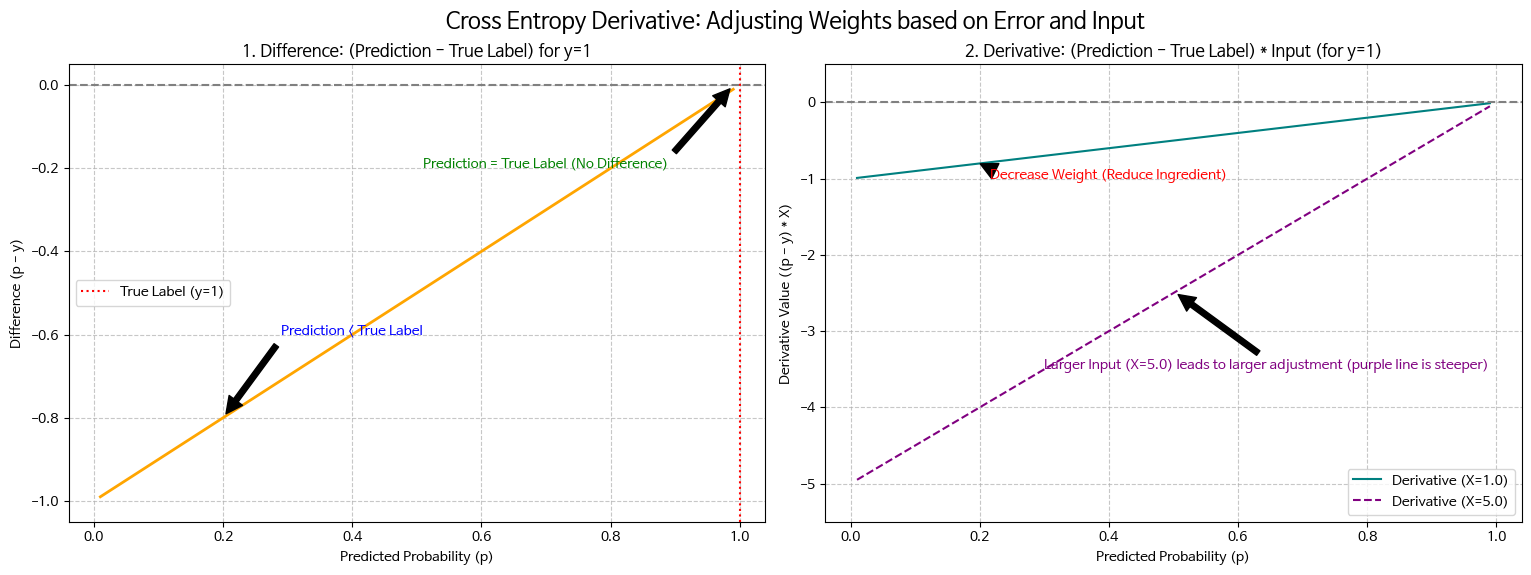

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 007 Visualization: Cross Entropy Derivative ---

# True Label (실제 손님 반응, '맛있다' = 1)로 고정
true_label_y = 1

# Predicted Probability (주방장 예측 확률) - 0.01에서 0.99까지
predicted_prob_p = np.linspace(0.01, 0.99, 100)

# Input Value (재료의 양) - 두 가지 시나리오를 위해 설정
input_x_small = 1.0 # 적은 양의 재료 (예: 소금)
input_x_large = 5.0 # 많은 양의 재료 (예: 설탕)

# 1. Prediction - True Label (H(X) - Y) 계산
diff_prediction_true = predicted_prob_p - true_label_y

# 2. Derivative (미분) 계산: (H(X) - Y) * X
derivative_small_x = diff_prediction_true * input_x_small
derivative_large_x = diff_prediction_true * input_x_large

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: (Prediction - True Label) ---
# 예측과 실제의 '맛 차이' 시각화
axes[0].plot(predicted_prob_p, diff_prediction_true, color='orange', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--') # 0점 기준선
axes[0].axvline(true_label_y, color='red', linestyle=':', label=f'True Label (y={true_label_y})') # 실제 정답 위치

axes[0].set_title('1. Difference: (Prediction - True Label) for y=1')
axes[0].set_xlabel('Predicted Probability (p)')
axes[0].set_ylabel('Difference (p - y)')
axes[0].set_ylim(-1.05, 0.05) # y=1 이므로 차이는 항상 음수 또는 0
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

axes[0].annotate('Prediction < True Label', xy=(0.2, -0.8), xytext=(0.4, -0.6),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center', color='blue')
axes[0].annotate('Prediction = True Label (No Difference)', xy=(0.99, 0), xytext=(0.7, -0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center', color='green')

# --- Subplot 2: Derivative (H(X) - Y) * X ---
# '재료 조절 지침' (미분 값) 시각화: 입력값(X)에 따른 변화
axes[1].plot(predicted_prob_p, derivative_small_x, color='teal', linestyle='-', label=f'Derivative (X={input_x_small})')
axes[1].plot(predicted_prob_p, derivative_large_x, color='purple', linestyle='--', label=f'Derivative (X={input_x_large})')
axes[1].axhline(0, color='gray', linestyle='--') # 0점 기준선

axes[1].set_title('2. Derivative: (Prediction - True Label) * Input (for y=1)')
axes[1].set_xlabel('Predicted Probability (p)')
axes[1].set_ylabel('Derivative Value ((p - y) * X)')
axes[1].set_ylim(-5.5, 0.5) # Y 축 범위 조정
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

axes[1].annotate('Decrease Weight (Reduce Ingredient)', xy=(0.2, derivative_small_x[np.argmin(np.abs(predicted_prob_p - 0.2))]),
                 xytext=(0.4, -1.0),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center', color='red')
axes[1].annotate(f'Larger Input (X={input_x_large}) leads to larger adjustment (purple line is steeper)',
                 xy=(0.5, derivative_large_x[np.argmin(np.abs(predicted_prob_p - 0.5))]), xytext=(0.3, -3.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='left', color='purple')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.suptitle('Cross Entropy Derivative: Adjusting Weights based on Error and Input', fontsize=16)
plt.show()

### 그래프 해석: 크로스 엔트로피 미분 (예측 오차와 입력값에 따른 가중치 조절)

위 그래프는 주방장(모델)이 요리(예측)를 한 뒤, 실제 손님 반응(정답)과 비교하여 '어떤 재료(가중치)를 얼마나, 어느 방향으로 조절해야 할지' 알려주는 미분의 역할을 시각적으로 보여줍니다.

**1. Difference: (Prediction - True Label) for y=1 - 왼쪽 그래프**
*   이 그래프는 모델의 예측 확률(`p`)과 실제 정답(`y=1`) 사이의 '차이'를 보여줍니다. 실제 정답이 '맛있다'(y=1)로 고정된 상황입니다.
*   **예측 확률(`p`)이 1에 가까울수록 (오른쪽으로 갈수록):** '차이' 값은 0에 가까워집니다. 모델이 정답에 가깝게 예측했다는 의미입니다.
*   **예측 확률(`p`)이 0에 가까울수록 (왼쪽으로 갈수록):** '차이' 값은 -1에 가까워집니다. 이는 모델이 실제 정답과 완전히 반대로 예측했다는 의미입니다.
*   이 '차이'는 다음 요리를 위해 **'재료를 조절할 방향'**을 지시하는 핵심 요소가 됩니다. 양수면 늘리고, 음수면 줄이라는 신호인 셈이죠.

**2. Derivative: (Prediction - True Label) * Input (for y=1) - 오른쪽 그래프**
*   이 그래프는 왼쪽에서 구한 '차이' 값에 '재료의 양'(입력값 `X`)을 곱하여 최종적인 **'재료 조절 지침'(미분 값)**이 어떻게 변하는지를 보여줍니다.
*   **미분 값의 부호:** 여전히 '예측 - 실제'의 부호를 따라갑니다. 만약 예측(`p`)이 실제(`y=1`)보다 작으면 미분 값은 음수가 되어 재료(가중치)를 '줄이라'고 지시합니다 (빨간색 화살표).
*   **미분 값의 크기 (기울기):**
    *   **입력값 `X` (재료의 양)이 클수록 (보라색 점선):** '차이'가 같더라도 '재료 조절 지침'의 절댓값이 더 커집니다. 예를 들어, 소금(`X=1.0`)을 조금 넣었다가 맛이 틀린 것과, 설탕(`X=5.0`)을 잔뜩 넣었다가 맛이 틀린 것 중 후자가 훨씬 더 강력하게 조절해야 할 필요가 있겠죠. 그래프에서 보라색 선의 기울기가 더 가파른 것은 입력값이 클수록 가중치 조절의 폭이 더 커진다는 것을 의미합니다.
    *   이는 모델이 학습 과정에서 **오류를 줄이기 위해 어떤 재료(가중치)를 얼마나 크게 또는 작게 수정해야 할지**를 알려주는 매우 중요한 정보가 됩니다.

이 두 그래프는 크로스 엔트로피 미분이 '예측 오류의 방향과 크기' 뿐만 아니라, 각 '입력값의 영향력'까지 고려하여 모델의 가중치를 업데이트하는 과정을 명확하게 보여줍니다.

**수학적 의미:**  
$$
\frac{dC}{dw} = (H(X) - Y) \cdot X
$$  

**생활 비유:**  
“예측과 실제의 차이 × 입력값 → 틀린 만큼 방향을 수정하는 공식.”  

**딥러닝 연결:**  
역전파에서 **오차 × 입력**으로 가중치를 업데이트합니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝 모델이 학습 과정에서 예측 오류(손실)를 줄이기 위해, 각 가중치(재료의 양)를 '얼마나, 어떤 방향으로' 조절해야 할지 알려주는 핵심 계산 값입니다. (역전파 알고리즘의 핵심)

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
요리가 맛이 없을 때, 주방장이 '소금은 조금 줄이고 설탕은 더 넣어봐야겠어!'처럼, 어떤 재료(가중치)를 '얼마나' 바꿀지 정확한 지침(미분 값)을 얻는 과정입니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
시험 점수가 낮을 때, '이 문제 유형은 이런 식으로 접근해야 점수가 더 잘 나와!'라고 구체적인 학습 방법을 알려주는 학습 가이드와 같습니다.

In [ ]:
import math

# 주방장(모델)의 예측 값 (예: '맛있다'고 예측할 확률)
예측_값 = 0.8 # 80% 확률로 맛있다

# 실제 손님 반응 (정답, 0 또는 1)
실제_값 = 1   # 실제로는 '맛있다'

# 요리 재료의 양 (입력값)
재료_양 = 2.0 # 예를 들어, 설탕의 양

# 예측과 실제의 차이 계산 (H(X) - Y)
# 맛있다(1)고 예측할 확률 0.8인데 실제도 맛있다(1) = 차이 -0.2 (음수면 예측이 실제보다 작음)
맛_차이 = 예측_값 - 실제_값

# 미분 값 계산 (간단화된 공식: (예측 - 실제) * 입력값)
# 이 미분 값은 재료의 양(가중치)을 얼마나, 어느 방향으로 바꿔야 할지 알려줍니다.
재료_조절_지침 = 맛_차이 * 재료_양

print(f"주방장 예측(맛있을 확률): {예측_값:.2f}")
print(f"실제 손님 반응(맛있다): {실제_값}")
print(f"재료의 양(설탕): {재료_양:.1f}")
print(f"\n맛 차이 (예측 - 실제): {맛_차이:.2f}")
print(f"재료 조절 지침 (미분 값): {재료_조절_지침:.2f}")

# 결과 해석:
# 재료 조절 지침이 음수면 해당 재료의 양을 줄여야 함
# 재료 조절 지침이 양수면 해당 재료의 양을 늘려야 함
# 현재 예시에서는 -0.4이므로, 설탕 양을 0.4만큼 줄여야 맛의 차이를 줄일 수 있다는 의미가 됩니다.
# (만약 예측이 0.8이고 실제가 0이었다면, 맛 차이 0.8, 재료 조절 지침 1.6이 되어 설탕 양을 늘리라는 지침이 되겠죠)

주방장 예측(맛있을 확률): 0.80
실제 손님 반응(맛있다): 1
재료의 양(설탕): 2.0

맛 차이 (예측 - 실제): -0.20
재료 조절 지침 (미분 값): -0.40


#### 💡 확인 문제: 007. 크로스 엔트로피 미분

Q1. 딥러닝에서 크로스 엔트로피 미분(Derivative)은 모델에게 어떤 정보를 제공하나요?

Q2. 요리 재료 조절 비유에서 '재료 조절 지침' (미분 값)은 주방장에게 무엇을 알려주나요?

Q3. 만약 '재료 조절 지침' (미분 값)이 음수(-)라면, 해당 재료의 양(가중치)은 어떻게 해야 할까요?

✅ **정답**

Q1. 모델이 예측 오류(손실)를 줄이기 위해 각 가중치를 '얼마나, 어떤 방향으로' 조절해야 할지 알려주는 핵심 계산 값을 제공합니다.

Q2. 예측한 맛과 실제 맛의 차이에 따라 각 재료(입력값)의 양을 어떻게 조절해야 할지 구체적인 방향과 크기를 알려줍니다.

Q3. 해당 재료의 양을 줄여야 합니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 008: Log Loss Behavior  

### 👨‍🍳 '맛' 예측의 치명적인 실수: 로그 손실의 경고

주방장이 요리의 맛을 예측할 때, '이건 분명히 100% 매운맛일 거야!'라고 확신했지만, 실제로는 '전혀 맵지 않은' 요리였다면 어떻게 될까요? 단순한 실수를 넘어 '상상도 할 수 없는' 큰 문제가 발생한 것이겠죠?

**로그 손실(Log Loss)** 은 이런 '치명적인 예측 실수'에 대해 강력한 경고를 날리는 벌점 시스템입니다. 만약 주방장이 정답이라고 생각한 맛에 대해 거의 '틀렸다'고 예측하거나, 반대로 '틀렸다'고 생각한 맛에 대해 거의 '정답'이라고 예측하면, 로그 손실은 끝없이 커지며 주방장에게 '정말 크게 잘못 생각했다!'고 소리칩니다. 이 덕분에 주방장은 극단적인 오판을 피하고 신중하게 예측하는 법을 배웁니다.



**수학적 의미:**  
- y=1일 때, 예측 확률이 0에 가까우면 손실 → 무한대  
- y=0일 때, 예측 확률이 1에 가까우면 손실 → 무한대  

**생활 비유:**  
“정답을 완전히 반대로 찍으면 벌점이 폭발하는 시험.”  

**딥러닝 연결:**  
Log Loss는 Cross Entropy의 특수한 경우로, **잘못된 확률 예측에 큰 페널티**를 줍니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝 모델이 어떤 것을 '확신'하고 예측했는데 그 예측이 '틀렸을 경우', 모델에 매우 큰 손실(벌점)을 주어 극단적인 오판을 강력하게 제어하는 역할을 합니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
주방장이 '이 요리는 100% 매운맛!'이라고 확신했는데 실제는 100% 안 매운맛이었다면, 로그 손실은 '상상 초월의 벌점'을 줘서 주방장이 다음엔 함부로 확신하지 못하게 합니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
시험에서 '이게 답이다!'라고 굳게 믿고 찍었는데 완전히 오답이었을 때, 그 한 문제로 점수가 엄청나게 깎이는 것과 같습니다.

In [ ]:
import math

# 실제 정답: 1 (실제로 매운 요리)
실제_정답_y = 1

# 주방장(모델)의 예측 확률:
예측_p_1 = 0.99  # 거의 100% 매울 것이라고 확신
예측_p_2 = 0.50  # 50% 매울 것이라고 예측 (반반)
예측_p_3 = 0.01  # 거의 0% 매울 것이라고 예측 (거의 안 매울 것이라고 확신)

# 로그 손실 계산 (실제 정답 y=1일 때): -log(p)
손실_1 = -math.log(예측_p_1)
손실_2 = -math.log(예측_p_2)
손실_3 = -math.log(예측_p_3)

print(f"실제 정답: {실제_정답_y} (매움)")
print("----------------------------------")
print(f"예측 확률 0.99 (거의 정답으로 예측): 손실 = {손실_1:.2f} (아주 작음)")
print(f"예측 확률 0.50 (반반 예측): 손실 = {손실_2:.2f} (중간)")
print(f"예측 확률 0.01 (거의 오답으로 예측): 손실 = {손실_3:.2f} (매우 큼! 치명적 실수!)")

# 주방장이 실제 정답(매움)을 '안 매움'으로 강하게 예측할수록 손실이 기하급수적으로 커지는 것을 볼 수 있습니다.

실제 정답: 1 (매움)
----------------------------------
예측 확률 0.99 (거의 정답으로 예측): 손실 = 0.01 (아주 작음)
예측 확률 0.50 (반반 예측): 손실 = 0.69 (중간)
예측 확률 0.01 (거의 오답으로 예측): 손실 = 4.61 (매우 큼! 치명적 실수!)


#### 💡 확인 문제: 008. 로그 손실의 경고

Q1. 딥러닝 모델이 매우 확신했지만 틀린 예측을 했을 때, 로그 손실(Log Loss)의 주요 특징은 무엇인가요?

Q2. 실제 정답이 1(예: '매움')인데 모델이 이를 0.01(거의 0)의 확률로 예측한다면, 로그 손실 벌점의 크기는 어떻게 되나요?

Q3. 로그 손실은 모델이 '치명적인 예측 실수'를 피하도록 어떻게 돕나요?

✅ **정답**

Q1. 모델이 잘못된 예측에 너무 강하게 확신할 때, 엄청나게 큰 손실(벌점)을 부여하여 극단적인 오판을 강력하게 제어합니다.

Q2. 벌점은 매우 커지게 됩니다 (예시에서는 4.61).

Q3. 극단적인 오판에 대해 무한대에 가까운 벌점을 주어 모델이 신중하게 예측하도록 훈련시킵니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 009: Cost Function Behavior (y=1, y=0 경우)  

### 👨‍🍳 '합격/불합격' 예측의 위험성: 손실 함수의 경고등 (y=1, y=0 경우)

주방장이 만든 요리가 '완벽하게 합격(y=1)'인지, 아니면 '완벽하게 불합격(y=0)'인지 예측하는 것은 매우 중요합니다. 그런데 주방장이 '합격'이라고 예측했는데 실제로는 '불합격'이었거나, 그 반대의 경우라면 큰일이겠죠?

**손실 함수**는 이런 상황에서 주방장에게 '경고등'을 켜줍니다. 만약 '합격'이어야 하는 요리를 '불합격'에 가깝게 예측하거나, '불합격'이어야 하는 요리를 '합격'에 가깝게 예측하면, 손실 함수는 엄청나게 큰 벌점을 줍니다. 이 벌점 시스템은 주방장이 극단적인 오판을 하지 않도록 강하게 훈련시켜, 언제나 신중하고 정확한 예측을 하도록 돕습니다.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


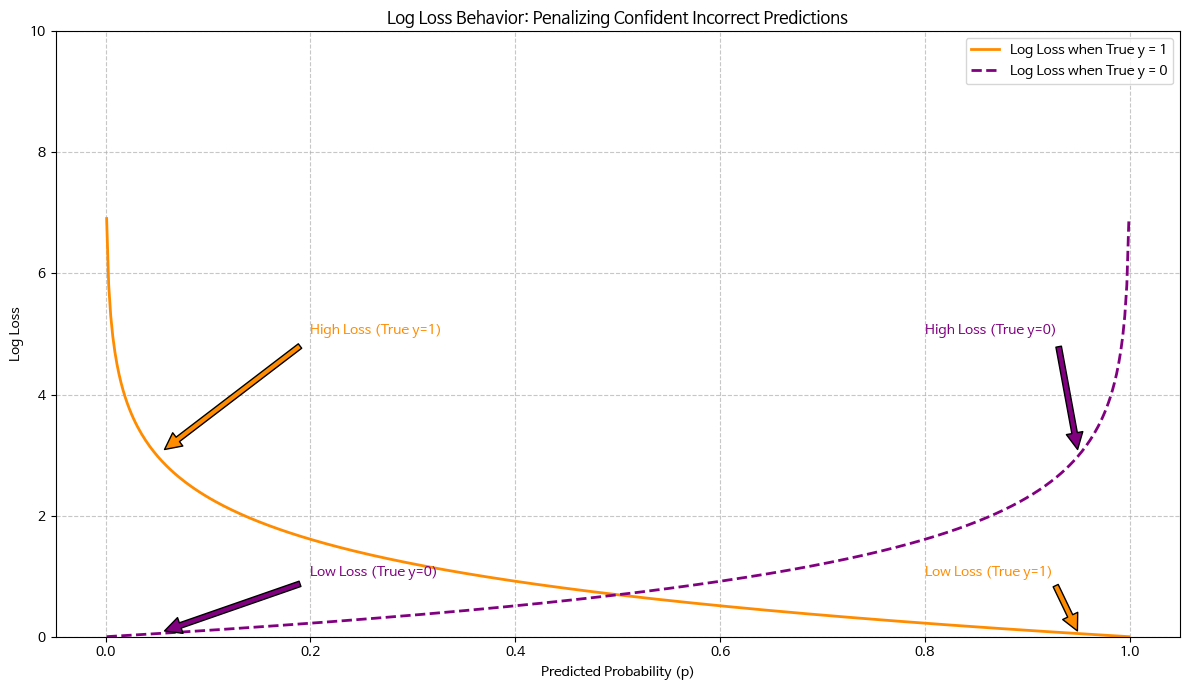

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 008 Visualization: Log Loss Behavior ---

# Predicted probability (p) ranging from a very small number to 1 - epsilon to avoid log(0)
p_range = np.linspace(0.001, 0.999, 500)

# Log Loss for y=1 (true label is positive)
# Loss = -log(p)
loss_when_y1 = -np.log(p_range)

# Log Loss for y=0 (true label is negative)
# Loss = -log(1-p)
loss_when_y0 = -np.log(1 - p_range)

fig = plt.figure(figsize=(12, 7))
plt.plot(p_range, loss_when_y1, label='Log Loss when True y = 1', color='darkorange', linewidth=2)
plt.plot(p_range, loss_when_y0, label='Log Loss when True y = 0', color='purple', linewidth=2, linestyle='--')

plt.title('Log Loss Behavior: Penalizing Confident Incorrect Predictions')
plt.xlabel('Predicted Probability (p)')
plt.ylabel('Log Loss')
plt.ylim(0, 10) # Limit y-axis for better visualization, showing the sharp rise
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Annotations for y=1 curve
plt.annotate('Low Loss (True y=1)', xy=(0.95, -np.log(0.95)), xytext=(0.8, 1),
             arrowprops=dict(facecolor='darkorange', shrink=0.05), fontsize=10, color='darkorange')
plt.annotate('High Loss (True y=1)', xy=(0.05, -np.log(0.05)), xytext=(0.2, 5),
             arrowprops=dict(facecolor='darkorange', shrink=0.05), fontsize=10, color='darkorange')

# Annotations for y=0 curve
plt.annotate('Low Loss (True y=0)', xy=(0.05, -np.log(1-0.05)), xytext=(0.2, 1),
             arrowprops=dict(facecolor='purple', shrink=0.05), fontsize=10, color='purple')
plt.annotate('High Loss (True y=0)', xy=(0.95, -np.log(1-0.95)), xytext=(0.8, 5),
             arrowprops=dict(facecolor='purple', shrink=0.05), fontsize=10, color='purple')

plt.tight_layout()
plt.show()

### 그래프 해석: 로그 손실(Log Loss)의 경고 동작

위 그래프는 '맛 예측의 치명적인 실수' 비유처럼, 딥러닝 모델이 예측한 확률 `p`에 따라 로그 손실이 어떻게 변화하는지를 시각적으로 보여줍니다. 특히, 모델이 '확신하지만 틀린 예측'을 했을 때 엄청난 벌점을 부여하는 로그 손실의 강력한 특성을 강조합니다.

**1. 주황색 선: 실제 정답이 1일 때의 로그 손실 (`True y = 1`)**
*   이 선은 실제 정답이 '1' (예: '맛있다')일 경우, 모델이 '맛있다'고 예측할 확률(`p`)에 따른 손실을 나타냅니다.
*   **`p`가 1에 가까울수록:** 손실은 0에 가까워집니다. 모델이 정답을 매우 정확하게 예측했으므로 벌점이 거의 없습니다.
*   **`p`가 0에 가까워질수록:** 손실은 급격하게 증가하여 무한대로 발산합니다. 실제 정답이 1인데, 모델이 이를 '절대 1이 아니다' (즉, 0에 가깝다)고 강하게 예측하면 엄청난 벌점을 받게 됩니다. 이는 모델의 '치명적인 실수'에 대한 강력한 경고입니다.

**2. 보라색 점선: 실제 정답이 0일 때의 로그 손실 (`True y = 0`)**
*   이 선은 실제 정답이 '0' (예: '맛없다')일 경우, 모델이 '맛있다'고 예측할 확률(`p`)에 따른 손실을 나타냅니다.
*   **`p`가 0에 가까울수록:** 손실은 0에 가까워집니다. 모델이 실제 정답이 0임을 매우 정확하게 예측했으므로 벌점이 거의 없습니다.
*   **`p`가 1에 가까워질수록:** 손실은 급격하게 증가하여 무한대로 발산합니다. 실제 정답이 0인데, 모델이 이를 '절대적으로 1이다' (즉, 1에 가깝다)고 강하게 예측하면 역시 엄청난 벌점을 받게 됩니다. 이는 '정답이 아닌 것을 정답이라고 확신'하는 '치명적인 오판'에 대한 경고입니다.

**핵심 요약:**
이 그래프는 로그 손실이 단순히 예측 오류의 크기만을 반영하는 것이 아니라, **모델의 '확신도(confidence)'까지 고려하여 벌점을 매긴다**는 것을 보여줍니다. 즉, 모델이 어정쩡하게 틀린 것보다, **강하게 확신했지만 틀린 예측에 대해서는 훨씬 더 큰 페널티**를 주어, 모델이 극단적인 오판을 피하고 항상 신중하고 정확하게 예측하도록 강력하게 유도하는 역할을 합니다.

### 그래프 해석: 로그 손실(Log Loss)의 경고 동작

위 그래프는 '맛 예측의 치명적인 실수' 비유처럼, 딥러닝 모델이 예측한 확률 `p`에 따라 로그 손실이 어떻게 변화하는지를 시각적으로 보여줍니다. 특히, 모델이 '확신하지만 틀린 예측'을 했을 때 엄청난 벌점을 부여하는 로그 손실의 강력한 특성을 강조합니다.

**1. 주황색 선: 실제 정답이 1일 때의 로그 손실 (`True y = 1`)**
*   이 선은 실제 정답이 '1' (예: '맛있다')일 경우, 모델이 '맛있다'고 예측할 확률(`p`)에 따른 손실을 나타냅니다.
*   **`p`가 1에 가까울수록:** 손실은 0에 가까워집니다. 모델이 정답을 매우 정확하게 예측했으므로 벌점이 거의 없습니다.
*   **`p`가 0에 가까워질수록:** 손실은 급격하게 증가하여 무한대로 발산합니다. 실제 정답이 1인데, 모델이 이를 '절대 1이 아니다' (즉, 0에 가깝다)고 강하게 예측하면 엄청난 벌점을 받게 됩니다. 이는 모델의 '치명적인 실수'에 대한 강력한 경고입니다.

**2. 보라색 점선: 실제 정답이 0일 때의 로그 손실 (`True y = 0`)**
*   이 선은 실제 정답이 '0' (예: '맛없다')일 경우, 모델이 '맛있다'고 예측할 확률(`p`)에 따른 손실을 나타냅니다.
*   **`p`가 0에 가까울수록:** 손실은 0에 가까워집니다. 모델이 실제 정답이 0임을 매우 정확하게 예측했으므로 벌점이 거의 없습니다.
*   **`p`가 1에 가까워질수록:** 손실은 급격하게 증가하여 무한대로 발산합니다. 실제 정답이 0인데, 모델이 이를 '절대적으로 1이다' (즉, 1에 가깝다)고 강하게 예측하면 역시 엄청난 벌점을 받게 됩니다. 이는 '정답이 아닌 것을 정답이라고 확신'하는 '치명적인 오판'에 대한 경고입니다.

**핵심 요약:**
이 그래프는 로그 손실이 단순히 예측 오류의 크기만을 반영하는 것이 아니라, **모델의 '확신도(confidence)'까지 고려하여 벌점을 매긴다**는 것을 보여줍니다. 즉, 모델이 어정쩡하게 틀린 것보다, **강하게 확신했지만 틀린 예측에 대해서는 훨씬 더 큰 페널티**를 주어, 모델이 극단적인 오판을 피하고 항상 신중하고 정확하게 예측하도록 강력하게 유도하는 역할을 합니다.



**수학적 의미:**  
- \( y=1 \)일 때, \( h_\theta(x) \)가 0에 가까우면 cost → 무한대  
- \( y=0 \)일 때, \( h_\theta(x) \)가 1에 가까우면 cost → 무한대  

**생활 비유:**  
“정답을 완전히 반대로 찍으면 벌점이 폭발하는 시험.”  

**딥러닝 연결:**  
Logistic Regression에서 **잘못된 확률 예측에 큰 페널티**를 주어 모델이 극단적인 실수를 피하도록 학습합니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝에서 이진 분류(예/아니오) 문제를 풀 때, 모델이 정답(y=1)을 오답(0에 가까운 예측)으로, 또는 오답(y=0)을 정답(1에 가까운 예측)으로 확신하면 무한대에 가까운 큰 벌점을 줍니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
요리가 '합격'인데 '불합격'이라고 강하게 예측하거나, '불합격'인데 '합격'이라고 강하게 예측하면, 손실 함수는 주방장에게 엄청난 '경고음'을 울려 잘못된 예측을 막습니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
주관식 문제에서 정답인데 '오답'으로 확신하거나, 오답인데 '정답'으로 확신하면, 점수가 바닥을 치는 것과 같이 모델에게 강력한 교훈을 줍니다.

In [ ]:
import math

# 실제 정답 (y=1: 합격, y=0: 불합격)
실제_결과 = 1 # 실제로는 '합격'

# 주방장(모델)의 예측 (0과 1 사이의 합격 확률)
예측_확률_1 = 0.99 # '합격'이라고 강하게 예측
예측_확률_2 = 0.01 # '불합격'이라고 강하게 예측 (실제는 합격인데 오판)

# 손실 함수 계산 (크로스 엔트로피)
def calculate_cost(y, p):
    # p가 0이나 1이 되는 극단적인 경우를 위해 아주 작은 값을 더해줍니다.
    p = max(min(p, 1 - 1e-10), 1e-10)
    cost = -y * math.log(p) - (1 - y) * math.log(1 - p)
    return cost

# y=1 (합격)일 때, 예측이 0.99 (합격에 가까움)
벌점_합격_예측_정확 = calculate_cost(실제_결과, 예측_확률_1)
print(f"실제: 합격(y=1), 예측: {예측_확률_1:.2f} (합격에 가까움) -> 벌점: {벌점_합격_예측_정확:.2f} (아주 작음)")

# y=1 (합격)일 때, 예측이 0.01 (불합격에 가까움)
벌점_합격_예측_오판 = calculate_cost(실제_결과, 예측_확률_2)
print(f"실제: 합격(y=1), 예측: {예측_확률_2:.2f} (불합격에 가까움) -> 벌점: {벌점_합격_예측_오판:.2f} (매우 큼!)")

# 실제_결과 = 0 (실제로는 '불합격')
실제_결과_불합격 = 0

# y=0 (불합격)일 때, 예측이 0.01 (불합격에 가까움)
벌점_불합격_예측_정확 = calculate_cost(실제_결과_불합격, 예측_확률_2)
print(f"실제: 불합격(y=0), 예측: {예측_확률_2:.2f} (불합격에 가까움) -> 벌점: {벌점_불합격_예측_정확:.2f} (아주 작음)")

# y=0 (불합격)일 때, 예측이 0.99 (합격에 가까움)
벌점_불합격_예측_오판 = calculate_cost(실제_결과_불합격, 예측_확률_1)
print(f"실제: 불합격(y=0), 예측: {예측_확률_1:.2f} (합격에 가까움) -> 벌점: {벌점_불합격_예측_오판:.2f} (매우 큼!)")

# 모델이 실제 정답과 반대로 강하게 예측할수록 벌점이 무한대로 치솟아,
# 극단적인 오판을 강력하게 경고하는 것을 볼 수 있습니다.

실제: 합격(y=1), 예측: 0.99 (합격에 가까움) -> 벌점: 0.01 (아주 작음)
실제: 합격(y=1), 예측: 0.01 (불합격에 가까움) -> 벌점: 4.61 (매우 큼!)
실제: 불합격(y=0), 예측: 0.01 (불합격에 가까움) -> 벌점: 0.01 (아주 작음)
실제: 불합격(y=0), 예측: 0.99 (합격에 가까움) -> 벌점: 4.61 (매우 큼!)


#### 💡 확인 문제: 009. 비용 함수 동작 (y=1, y=0 경우)

Q1. 이진 분류에서 모델이 실제 정답이 0(예: '불합격')인데, 1(예: '합격')에 가깝게 매우 확신하여 예측한다면 손실(Cost)은 어떻게 되나요?

Q2. 손실 함수가 '매우 큰' 벌점을 부여하여 모델이 극단적인 실수를 피하도록 하는 이유는 무엇인가요?

Q3. 파이썬 예시에서 `실제: 합격(y=1)`인데 `예측: 0.01 (불합격에 가까움)`인 경우의 벌점은 무엇을 의미하나요?

✅ **정답**

Q1. 손실은 무한대에 가까운 매우 큰 값으로 증가하여 강력한 벌점을 받습니다.

Q2. 모델이 잘못된 확률 예측에 대해 큰 페널티를 받도록 하여, 극단적인 오판을 강력하게 경고하고 학습 방향을 제시하기 위함입니다.

Q3. 모델이 실제 정답과 완전히 반대로 확신하여 예측했기 때문에, 4.61이라는 매우 큰 벌점을 받는 것을 의미합니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 010: Cross Entropy Derivative (미분)  

### 👨‍🍳 요리사의 '맛 조절' 지침서: 크로스 엔트로피 미분 (다시 한번!)

요리사의 꿈은 항상 최고의 맛을 내는 것이죠. 그런데 요리가 조금 부족하다고 느껴질 때, '어떤 재료를 얼마나 바꿔야' 완벽한 맛에 도달할 수 있을까요? 감으로만 해서는 절대 안 됩니다!

여기서 **크로스 엔트로피의 미분(Derivative)**이 다시 한번 중요한 역할을 합니다. 이것은 마치 요리사가 맛을 본 후, '예측한 맛'과 '실제 손님이 원하는 맛'의 차이를 바탕으로, 각 재료(입력값)가 요리의 맛에 얼마나 영향을 미쳤는지를 계산하는 과정입니다. 이 계산을 통해 '어떤 재료를 얼마만큼 줄이거나 늘려야 할지' 정확한 지침을 얻어, 다음 요리에서는 훨씬 더 나은 맛을 만들 수 있게 됩니다.


### 📊 시각화: 크로스 엔트로피 미분 (가중치 조정 지침)

아래 그래프는 주방장(모델)이 요리(예측)를 한 후, 실제 손님 반응(정답)과 비교하여 '어떤 재료(가중치)를 얼마나, 어느 방향으로 조절해야 할지' 알려주는 미분의 역할을 시각적으로 보여줍니다.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


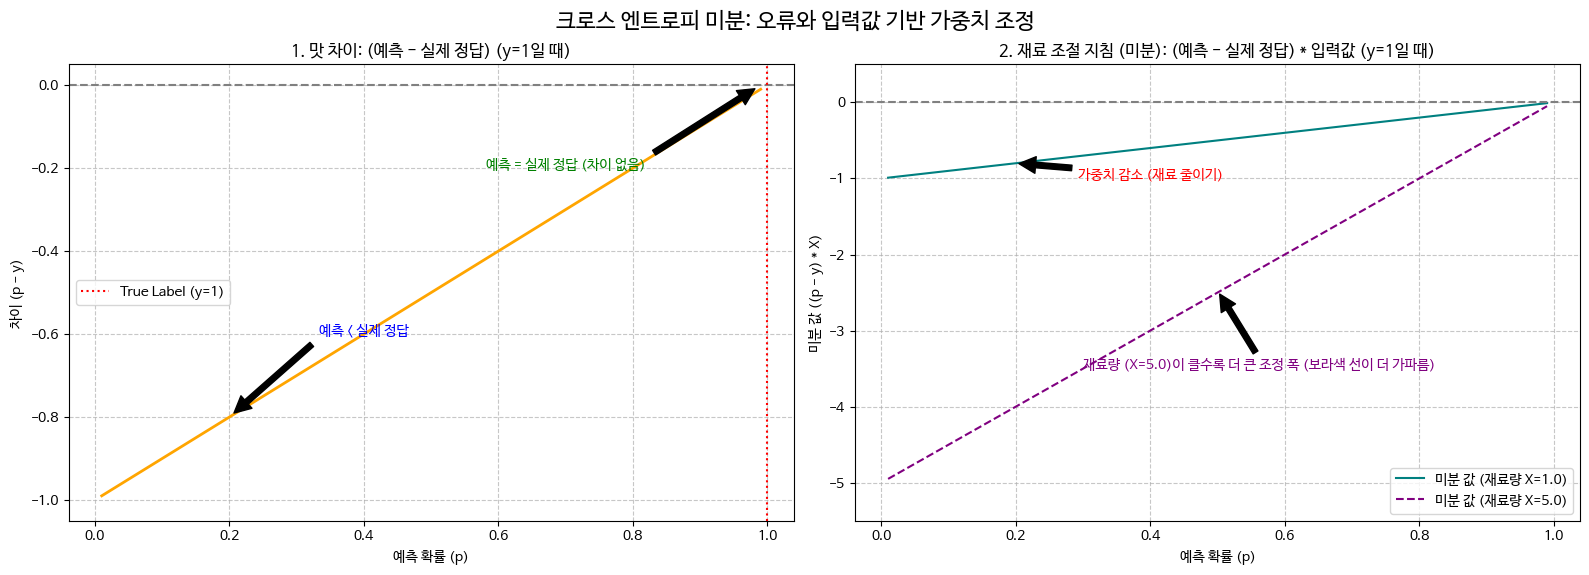

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 010 Visualization: Cross Entropy Derivative (Again) ---

# True Label (실제 손님 반응, '맛있다' = 1)로 고정
true_label_y = 1

# Predicted Probability (주방장 예측 확률) - 0.01에서 0.99까지
predicted_prob_p = np.linspace(0.01, 0.99, 100)

# Input Value (재료의 양) - 두 가지 시나리오를 위해 설정
input_x_small = 1.0 # 적은 양의 재료 (예: 소금)
input_x_large = 5.0 # 많은 양의 재료 (예: 설탕)

# 1. Prediction - True Label (H(X) - Y) 계산
diff_prediction_true = predicted_prob_p - true_label_y

# 2. Derivative (미분) 계산: (H(X) - Y) * X
derivative_small_x = diff_prediction_true * input_x_small
derivative_large_x = diff_prediction_true * input_x_large

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: (Prediction - True Label) ---
# 예측과 실제의 '맛 차이' 시각화
axes[0].plot(predicted_prob_p, diff_prediction_true, color='orange', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--') # 0점 기준선
axes[0].axvline(true_label_y, color='red', linestyle=':', label=f'True Label (y={true_label_y})') # 실제 정답 위치

axes[0].set_title('1. 맛 차이: (예측 - 실제 정답) (y=1일 때)')
axes[0].set_xlabel('예측 확률 (p)')
axes[0].set_ylabel('차이 (p - y)')
axes[0].set_ylim(-1.05, 0.05) # y=1 이므로 차이는 항상 음수 또는 0
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

axes[0].annotate('예측 < 실제 정답', xy=(0.2, -0.8), xytext=(0.4, -0.6),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center', color='blue')
axes[0].annotate('예측 = 실제 정답 (차이 없음)', xy=(0.99, 0), xytext=(0.7, -0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center', color='green')

# --- Subplot 2: Derivative (H(X) - Y) * X ---
# '재료 조절 지침' (미분 값) 시각화: 입력값(X)에 따른 변화
axes[1].plot(predicted_prob_p, derivative_small_x, color='teal', linestyle='-', label=f'미분 값 (재료량 X={input_x_small})')
axes[1].plot(predicted_prob_p, derivative_large_x, color='purple', linestyle='--', label=f'미분 값 (재료량 X={input_x_large})')
axes[1].axhline(0, color='gray', linestyle='--') # 0점 기준선

axes[1].set_title('2. 재료 조절 지침 (미분): (예측 - 실제 정답) * 입력값 (y=1일 때)')
axes[1].set_xlabel('예측 확률 (p)')
axes[1].set_ylabel('미분 값 ((p - y) * X)')
axes[1].set_ylim(-5.5, 0.5) # Y 축 범위 조정
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

axes[1].annotate('가중치 감소 (재료 줄이기)', xy=(0.2, derivative_small_x[np.argmin(np.abs(predicted_prob_p - 0.2))]),
                 xytext=(0.4, -1.0),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center', color='red')
axes[1].annotate(f'재료량 (X={input_x_large})이 클수록 더 큰 조정 폭 (보라색 선이 더 가파름)',
                 xy=(0.5, derivative_large_x[np.argmin(np.abs(predicted_prob_p - 0.5))]), xytext=(0.3, -3.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='left', color='purple')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.suptitle('크로스 엔트로피 미분: 오류와 입력값 기반 가중치 조정', fontsize=16)
plt.show()

### 그래프 해석: 크로스 엔트로피 미분 (예측 오류와 입력값에 따른 가중치 조절)

위 그래프는 주방장(모델)이 요리(예측)를 한 뒤, 실제 손님 반응(정답)과 비교하여 '어떤 재료(가중치)를 얼마나, 어느 방향으로 조절해야 할지' 알려주는 미분의 역할을 시각적으로 보여줍니다.

**1. 맛 차이: (예측 - 실제 정답) (y=1일 때) - 왼쪽 그래프**
*   이 그래프는 모델의 예측 확률(`p`)과 실제 정답(`y=1`) 사이의 '차이'를 보여줍니다. 실제 정답이 '맛있다'(y=1)로 고정된 상황입니다.
*   **예측 확률(`p`)이 1에 가까울수록 (오른쪽으로 갈수록):** '차이' 값은 0에 가까워집니다. 모델이 정답에 가깝게 예측했다는 의미입니다.
*   **예측 확률(`p`)이 0에 가까울수록 (왼쪽으로 갈수록):** '차이' 값은 -1에 가까워집니다. 이는 모델이 실제 정답과 완전히 반대로 예측했다는 의미입니다.
*   이 '차이'는 다음 요리를 위해 **'재료를 조절할 방향'**을 지시하는 핵심 요소가 됩니다. 양수면 늘리고, 음수면 줄이라는 신호인 셈이죠.

**2. 재료 조절 지침 (미분): (예측 - 실제 정답) * 입력값 (y=1일 때) - 오른쪽 그래프**
*   이 그래프는 왼쪽에서 구한 '차이' 값에 '재료의 양'(입력값 `X`)을 곱하여 최종적인 **'재료 조절 지침'(미분 값)**이 어떻게 변하는지를 보여줍니다.
*   **미분 값의 부호:** 여전히 '예측 - 실제'의 부호를 따라갑니다. 만약 예측(`p`)이 실제(`y=1`)보다 작으면 미분 값은 음수가 되어 재료(가중치)를 '줄이라'고 지시합니다 (빨간색 화살표).
*   **미분 값의 크기 (기울기):**
    *   **입력값 `X` (재료의 양)이 클수록 (보라색 점선):** '차이'가 같더라도 '재료 조절 지침'의 절댓값이 더 커집니다. 예를 들어, 소금(`X=1.0`)을 조금 넣었다가 맛이 틀린 것과, 설탕(`X=5.0`)을 잔뜩 넣었다가 맛이 틀린 것 중 후자가 훨씬 더 강력하게 조절해야 할 필요가 있겠죠. 그래프에서 보라색 선의 기울기가 더 가파른 것은 입력값이 클수록 가중치 조절의 폭이 더 커진다는 것을 의미합니다.
    *   이는 모델이 학습 과정에서 **오류를 줄이기 위해 어떤 재료(가중치)를 얼마나 크게 또는 작게 수정해야 할지**를 알려주는 매우 중요한 정보가 됩니다.

이 두 그래프는 크로스 엔트로피 미분이 '예측 오류의 방향과 크기' 뿐만 아니라, 각 '입력값의 영향력'까지 고려하여 모델의 가중치를 업데이트하는 과정을 명확하게 보여줍니다.

**수학적 의미:**  
$$
\frac{dC}{dw} = (H(X) - Y) \cdot X
$$  

**생활 비유:**  
“예측과 실제 차이 × 입력값 → 틀린 만큼 방향을 수정하는 공식.”  

**딥러닝 연결:**  
역전파에서 **오차 × 입력**으로 가중치를 업데이트하는 핵심 원리입니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝 모델이 학습을 통해 최적의 성능을 찾기 위해, 현재 예측의 오류를 바탕으로 각 매개변수(가중치)를 어떤 방향으로, 얼마나 수정해야 할지 계산하는 핵심 단계입니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
요리 맛 평가 후, '이 맛을 내려면 이 재료는 이만큼, 저 재료는 저만큼 조절해야 해!'라는 구체적인 지시를 얻어 다음 요리에 반영하는 것과 같습니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
목표 점수와 현재 점수의 차이를 분석하여, 다음에는 어떤 공부 방법을 사용해야 더 효율적으로 점수를 올릴 수 있을지 알려주는 비법 노트와 같습니다.

In [ ]:
import math

# 주방장(모델)의 예측 값 (예: '맛있다'고 예측할 확률)
예측_값 = 0.8 # 80% 확률로 맛있다

# 실제 손님 반응 (정답, 0 또는 1)
실제_값 = 1   # 실제로는 '맛있다'

# 요리 재료의 양 (입력값)
재료_양 = 2.0 # 예를 들어, 설탕의 양

# 예측과 실제의 차이 계산 (H(X) - Y)
# 맛있다(1)고 예측할 확률 0.8인데 실제도 맛있다(1) = 차이 -0.2 (음수면 예측이 실제보다 작음)
맛_차이 = 예측_값 - 실제_값

# 미분 값 계산 (간단화된 공식: (예측 - 실제) * 입력값)
# 이 미분 값은 재료의 양(가중치)을 얼마나, 어느 방향으로 바꿔야 할지 알려줍니다.
재료_조절_지침 = 맛_차이 * 재료_양

print(f"주방장 예측(맛있을 확률): {예측_값:.2f}")
print(f"실제 손님 반응(맛있다): {실제_값}")
print(f"재료의 양(설탕): {재료_양:.1f}")
print(f"\n맛 차이 (예측 - 실제): {맛_차이:.2f}")
print(f"재료 조절 지침 (미분 값): {재료_조절_지침:.2f}")

# 결과 해석:
# 재료 조절 지침이 음수면 해당 재료의 양을 줄여야 함
# 재료 조절 지침이 양수면 해당 재료의 양을 늘려야 함
# 현재 예시에서는 -0.4이므로, 설탕 양을 0.4만큼 줄여야 맛의 차이를 줄일 수 있다는 의미가 됩니다.
# (만약 예측이 0.8이고 실제가 0이었다면, 맛 차이 0.8, 재료 조절 지침 1.6이 되어 설탕 양을 늘리라는 지침이 되겠죠)

주방장 예측(맛있을 확률): 0.80
실제 손님 반응(맛있다): 1
재료의 양(설탕): 2.0

맛 차이 (예측 - 실제): -0.20
재료 조절 지침 (미분 값): -0.40


#### 💡 확인 문제: 010. 크로스 엔트로피 미분 (다시 한번!)

Q1. 딥러닝 모델이 학습을 통해 최적의 성능을 찾기 위해 크로스 엔트로피 미분(Derivative)을 사용하는 주된 목적은 무엇인가요?

Q2. 미분 값(예: `재료_조절_지침`)은 모델이 내부 매개변수(가중치)를 어떻게 조정하도록 직접적으로 영향을 미치나요?

Q3. 만약 주방장의 예측 맛이 실제 원하는 맛보다 너무 높아서 미분 값이 양수(+)로 나왔다면, 주방장은 해당 재료의 양을 어떻게 해야 할까요?

✅ **정답**

Q1. 현재 예측의 오류를 바탕으로 각 매개변수(가중치)를 어떤 방향으로, 얼마나 수정해야 할지 계산하여 모델을 똑똑하게 만드는 것입니다.

Q2. 미분 값의 부호는 조정할 방향(증가/감소)을, 크기는 조정할 양을 알려주어, 모델이 손실을 줄이는 방향으로 가중치를 업데이트하도록 합니다.

Q3. 해당 재료의 양을 늘려야 합니다. (미분 값이 양수면 해당 재료의 양을 늘려야 맛의 차이가 줄어든다는 의미)


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 011: Log Loss (y=1일 때)  

### 👨‍🍳 '정답 요리'를 맞히는 자의 점수 (y=1일 때): 로그 손실의 보상과 벌칙

손님(정답)이 '이 요리는 완벽해!' (y=1)라고 말했을 때, 주방장(모델)의 예측은 어떠해야 할까요? 당연히 '완벽하다!'에 가까울수록 좋습니다. 하지만 만약 '완벽하다!'라고 예측했음에도 실제로는 맛이 없었다면 어떻게 될까요?

**로그 손실(Log Loss)** 은 '정답 요리' 상황에서의 점수 규칙을 명확히 합니다. 주방장이 '완벽하다!'에 가깝게 예측할수록 벌점은 거의 없습니다. 하지만 '완벽하다!'라고 해야 할 요리를 '전혀 아니다!'에 가깝게 예측하면, 로그 손실은 끝없이 커지며 엄청난 벌점을 부여합니다. 이는 주방장이 '정답'인 상황에서 절대 엉뚱한 예측을 하지 않도록 강력하게 유도합니다.


### 📊 시각화: 로그 손실 함수 (실제 정답 y=1일 때)

아래 그래프는 실제 정답 `y`가 1일 때, 주방장(모델)의 예측 확률 `p`에 따라 로그 손실이 어떻게 변화하는지를 시각적으로 보여줍니다. 모델이 실제 정답을 얼마나 정확하게 예측하는지에 따라 벌점이 어떻게 달라지는지 확인해 보세요.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


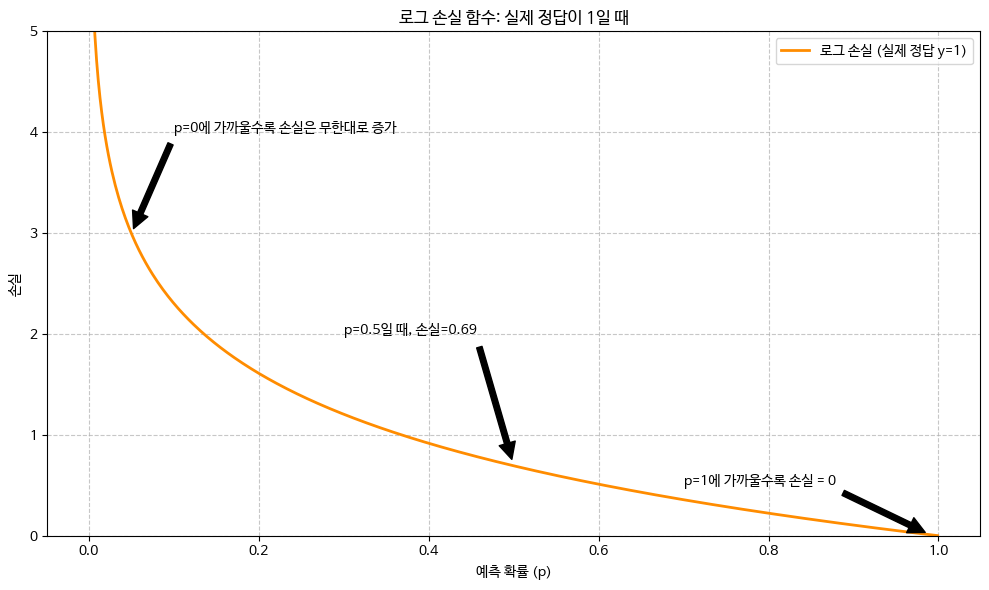

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 011 Visualization: Log Loss (y=1) ---

# Predicted probability (p) ranging from a very small number to 1 - epsilon to avoid log(0)
# log 함수는 p가 0에 가까워지면 무한대로 발산하므로, 0.001부터 시작합니다.
p = np.linspace(0.001, 0.999, 500)

# Log Loss function when the actual answer is 1: -log(p)
loss_y_eq_1 = -np.log(p)

fig = plt.figure(figsize=(10, 6))
plt.plot(p, loss_y_eq_1, label='로그 손실 (실제 정답 y=1)', color='darkorange', linewidth=2)
plt.xlabel('예측 확률 (p)')
plt.ylabel('손실')
plt.title('로그 손실 함수: 실제 정답이 1일 때')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 5) # y축 범위를 제한하여 극단적인 값을 제외하고 시각화 개선

# 주요 지점에 주석 추가
plt.annotate(f'p=1에 가까울수록 손실 = 0', xy=(0.99, -np.log(0.99)), xytext=(0.7, 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate(f'p=0.5일 때, 손실={-np.log(0.5):.2f}', xy=(0.5, -np.log(0.5)), xytext=(0.3, 2),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate('p=0에 가까울수록 손실은 무한대로 증가', xy=(0.05, -np.log(0.05)), xytext=(0.1, 4),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

### 그래프 해석: 로그 손실 함수 (실제 정답 y=1일 때)

위 그래프는 실제 정답 `y`가 1일 때 (즉, 손님이 '완벽한 요리'라고 평가했을 때), 주방장(모델)의 예측 확률 `p`에 따라 로그 손실이 어떻게 변화하는지 보여줍니다. 이 그래프는 특히 '수학적 의미'에서 설명하는 로그 손실의 특징을 시각적으로 나타냅니다.

*   **예측 확률 `p`가 1에 가까워질수록 (오른쪽으로 갈수록):** 손실 값은 거의 0에 수렴합니다. 이는 모델이 실제 정답을 매우 정확하게 예측했을 때 벌점이 거의 없다는 것을 의미합니다. **수학적 의미: 예측 확률이 1에 가까울수록 손실 → 0**

*   **예측 확률 `p`가 0.5일 때:** 손실은 약 `0.69`입니다. 이는 모델이 정답인지 오답인지 '반반'으로 예측했을 때 받는 벌점입니다.

*   **예측 확률 `p`가 0에 가까워질수록 (왼쪽으로 갈수록):** 손실 값은 급격하게 증가하여 무한대로 발산합니다. 이는 모델이 실제 정답(`y=1`)인데도 불구하고, 정답이 아닐 것이라고 강하게 예측(`p`가 0에 가까움)하면 어마어마하게 큰 벌점을 받는다는 것을 나타냅니다. **수학적 의미: 예측 확률이 0에 가까울수록 손실 → 무한대**

이러한 로그 손실 함수의 특성 덕분에 딥러닝 모델은 실제 정답이 1인 경우, 잘못된 예측을 하거나 '이것은 1이 아닐 것'이라고 강하게 확신하는 예측에 대해 매우 강력한 페널티를 받아, 점차 정확한 예측을 하는 방향으로 가중치를 조정하게 됩니다.


**수학적 의미:**  
예측 확률이 1에 가까울수록 손실 → 0,  
예측 확률이 0에 가까울수록 손실 → 무한대.  

**생활 비유:**  
“정답을 맞히면 벌점이 거의 없지만, 정답을 완전히 반대로 찍으면 벌점이 폭발.”  

**딥러닝 연결:**  
Log Loss는 Cross Entropy의 특수한 경우로, **확률 예측의 정확성**을 직접적으로 평가합니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
실제 정답이 1인 경우(긍정 클래스), 딥러닝 모델의 예측 확률이 1에 가까울수록 손실을 거의 주지 않고, 0에 가까울수록 무한대에 가까운 큰 손실을 주어 정확한 예측을 유도합니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
손님이 '이 요리 완벽해!(정답 1)'라고 했을 때, 주방장이 '완벽합니다!(예측 1)'라고 예측하면 칭찬(손실 없음), '맛없어요!(예측 0)'라고 예측하면 엄청난 벌점(무한대 손실)을 받는 것과 같습니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
정답인 문제를 정확히 맞히면 점수를 얻지만, 정답인데 오답으로 강하게 찍으면 엄청난 감점을 받는 시험 채점 방식과 같습니다.

In [ ]:
import math

# 실제 정답: 1 (예: 이 요리는 '맛있다')
실제_값_y = 1

# 주방장(모델)의 예측 확률 (0과 1 사이의 값)
예측_p_아주정확 = 0.99  # '맛있다'고 아주 강하게 예측
예측_p_중간 = 0.50     # '맛있다'고 반반으로 예측
예측_p_아주틀림 = 0.01  # '맛없다'고 아주 강하게 예측 (오판)

# 로그 손실 계산 (y=1일 때): -log(p)
손실_아주정확 = -math.log(예측_p_아주정확)
손실_중간 = -math.log(예측_p_중간)
손실_아주틀림 = -math.log(예측_p_아주틀림)

print(f"실제 정답 (y): {실제_값_y} (요리는 맛있다)")
print("----------------------------------")
print(f"예측 확률 0.99: 손실 = {손실_아주정확:.2f} (거의 벌점 없음)")
print(f"예측 확률 0.50: 손실 = {손실_중간:.2f} (중간 벌점)")
print(f"예측 확률 0.01: 손실 = {손실_아주틀림:.2f} (매우 큰 벌점!)")

# 실제 정답이 '1'인데, 주방장이 '0'에 가깝게 예측할수록 벌점이 엄청나게 커지는 것을 볼 수 있습니다.
# 이는 모델이 정답인 상황에서 잘못된 예측을 강력하게 피하도록 만듭니다.

실제 정답 (y): 1 (요리는 맛있다)
----------------------------------
예측 확률 0.99: 손실 = 0.01 (거의 벌점 없음)
예측 확률 0.50: 손실 = 0.69 (중간 벌점)
예측 확률 0.01: 손실 = 4.61 (매우 큰 벌점!)


#### 💡 확인 문제: 011. 로그 손실 (y=1일 때)

Q1. 실제 정답이 1(예: '이 요리는 완벽해!')일 때, 모델이 1에 매우 가까운 확률(예: 0.99)로 예측한다면 로그 손실(Log Loss) 벌점은 대략 얼마가 되나요?

Q2. 반대로 실제 정답이 1인데 모델이 0에 매우 가까운 확률(예: 0.01)로 예측한다면 로그 손실 벌점은 어떻게 되나요?

Q3. `y=1`인 경우, 확신하지만 틀린 예측에 대해 '무한대에 가까운 벌점'을 주는 것은 모델에게 어떤 학습 효과를 가져오나요?

✅ **정답**

Q1. 거의 벌점이 없습니다 (예시에서는 0.01).

Q2. 무한대에 가까운 매우 큰 벌점을 받습니다 (예시에서는 4.61).

Q3. 모델이 '정답'인 상황에서 절대 엉뚱한 예측을 하지 않도록 강력하게 유도하고, 정확한 예측을 하도록 훈련시킵니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 012: -log(y) vs log(y)

### 👨‍🍳 '벌점'이 양수가 되어야 하는 이유: -log(y) vs log(y)

요리 경연대회에서 '벌점'은 항상 '음수'가 아닌 '양수'여야 합니다. 그리고 실수가 클수록 벌점도 커져야겠죠? 그런데 수학에서 사용하는 평범한 '로그(log(y))' 함수는 예측값이 1보다 작으면 오히려 '음수'가 되거나, 0에 가까워질수록 벌점이 줄어드는 것처럼 보일 수 있습니다.

그래서 우리는 이 벌점을 제대로 표현하기 위해 특별한 방법인 **'-로그(y)'** 를 사용합니다. 이 방법은 예측값이 0에 가까워질수록 벌점을 '양수'로, 그것도 '무한대'에 가깝게 크게 만들어서, 주방장(모델)이 작은 실수를 했을 때도 제대로 혼나고, 큰 실수는 더욱 크게 반성하도록 돕습니다.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


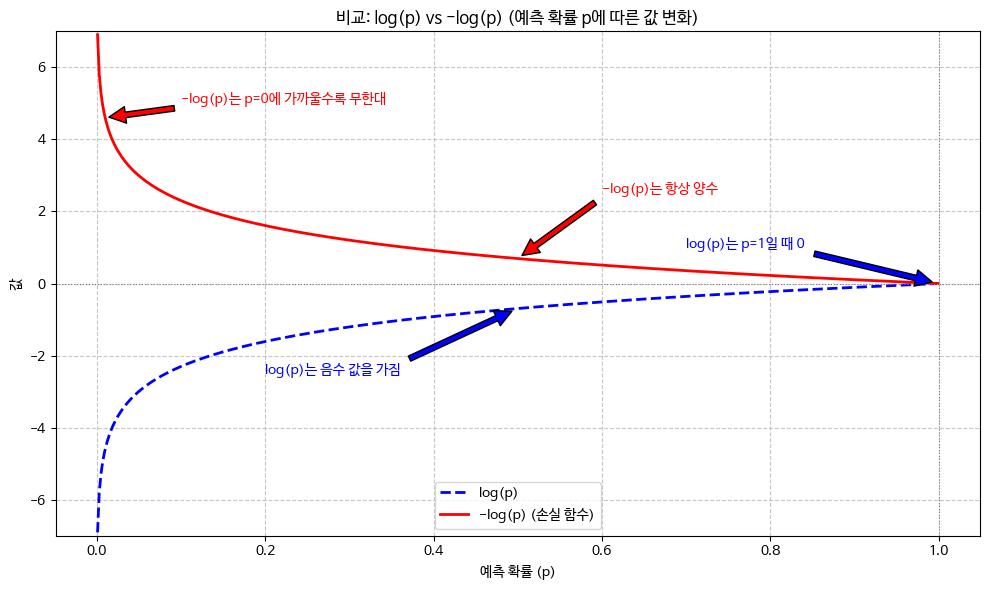

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 012 Visualization: -log(y) vs log(y) ---

# Predicted probability (p) ranging from a very small number to 1 - epsilon to avoid log(0)
p_range = np.linspace(0.001, 0.999, 500)

# Calculate log(p) and -log(p)
log_p = np.log(p_range)
minus_log_p = -np.log(p_range)

fig = plt.figure(figsize=(10, 6))
plt.plot(p_range, log_p, label='log(p)', color='blue', linestyle='--', linewidth=2)
plt.plot(p_range, minus_log_p, label='-log(p) (손실 함수)', color='red', linewidth=2)

plt.axhline(0, color='gray', linestyle=':', linewidth=0.8) # 0점 기준선
plt.axvline(1, color='gray', linestyle=':', linewidth=0.8) # p=1 기준선

plt.title('비교: log(p) vs -log(p) (예측 확률 p에 따른 값 변화)')
plt.xlabel('예측 확률 (p)')
plt.ylabel('값')
plt.ylim(-7, 7) # Y축 범위를 제한하여 시각화 개선
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Annotations
plt.annotate('log(p)는 음수 값을 가짐', xy=(0.5, np.log(0.5)), xytext=(0.2, -2.5),
             arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=10, color='blue')
plt.annotate('log(p)는 p=1일 때 0', xy=(1, np.log(1)), xytext=(0.7, 1),
             arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=10, color='blue')

plt.annotate('-log(p)는 항상 양수', xy=(0.5, -np.log(0.5)), xytext=(0.6, 2.5),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=10, color='red')
plt.annotate('-log(p)는 p=0에 가까울수록 무한대', xy=(0.01, -np.log(0.01)), xytext=(0.1, 5),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=10, color='red')

plt.tight_layout()
plt.show()

### 그래프 해석: `log(p)` vs `-log(p)` (예측 확률 p에 따른 값 변화)

위 그래프는 주방장(모델)의 예측 확률 `p`에 따라 일반적인 로그 함수 `log(p)`와 딥러닝 손실 함수에서 주로 사용하는 `-log(p)`의 값이 어떻게 변화하는지를 비교하여 보여줍니다. 이 시각화는 손실 함수가 '벌점'을 매기는 수학적 의미를 명확히 이해하는 데 도움을 줍니다.

*   **파란색 점선: `log(p)`**
    *   `p`가 1일 때 `log(1)`은 0입니다.
    *   `p`가 0과 1 사이일 때 `log(p)`는 음수 값을 가집니다. 즉, 예측 확률이 1보다 작으면 값이 마이너스가 됩니다. 이는 '벌점'이 항상 양수여야 하는 딥러닝 손실 함수의 목적에 부합하지 않습니다.
    *   `p`가 0에 가까워질수록 `log(p)`는 음의 무한대(`-∞`)로 발산합니다.

*   **빨간색 실선: `-log(p)` (딥러닝 손실 함수의 핵심)**
    *   이 그래프는 `log(p)` 그래프를 x축에 대해 뒤집어 놓은 형태입니다.
    *   `p`가 1일 때 `-log(1)`은 0입니다. 모델이 완벽하게 예측하면 벌점이 없습니다.
    *   `p`가 0과 1 사이일 때 `-log(p)`는 항상 양수 값을 가집니다. 이는 벌점이 음수가 될 수 없다는 직관과 일치합니다.
    *   **수학적 의미:** `p`가 0에 가까워질수록 `-log(p)`는 양의 무한대(`+∞`)로 급격하게 발산합니다. 이는 모델이 '정답(y=1)'인데도 불구하고 '정답이 아닐 것'이라고 강하게 예측(`p`가 0에 가까움)하면, 엄청나게 큰 벌점을 주어 극단적인 오판을 강력하게 제어하는 효과를 가져옵니다.

**핵심 요약:** 딥러닝에서 손실 함수는 모델의 '잘못된 예측'에 대해 벌점을 부여하는 역할을 합니다. 이때 벌점은 항상 양수여야 하고, 예측이 크게 틀릴수록 벌점도 크게 증가해야 합니다. `log(p)`는 음수 값을 가질 수 있기 때문에 직접적으로 벌점으로 사용하기 어렵지만, `-log(p)`는 이러한 조건(항상 양수, 잘못된 예측에 대한 무한대 벌점)을 완벽하게 충족하므로, 모델이 올바른 방향으로 학습하도록 유도하는 데 필수적인 수학적 도구입니다.


**수학적 의미:**  
- \( \log(y) \): \( y < 1 \)이면 음수  
- \( -\log(y) \): \( y \)가 0에 가까울수록 값이 커짐  

**생활 비유:**  
“작은 확률을 예측하면 벌점이 크게 늘어나는 구조.”  

**딥러닝 연결:**  
Cross Entropy는 **잘못된 확률 예측을 강하게 벌주는 구조**로 설계되어 있습니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
딥러닝 손실 함수에서 예측 오차에 대한 '벌점'을 항상 양수로 만들고, 오류가 커질수록 벌점도 무한대로 커지게 하여 모델이 잘못된 예측을 강력하게 피하도록 유도하는 수학적 기법입니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
요리 평가에서 벌점은 항상 긍정적이어야 하고, 실수가 클수록 벌점도 커져야 하므로, 일반적인 '로그' 대신 '마이너스 로그'를 사용하여 주방장이 실수를 명확히 인지하게 합니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
시험 점수를 매길 때, 틀린 문제에 대한 감점을 항상 양수로 크게 매겨 학생들이 왜 틀렸는지 명확히 알게 하는 방법입니다.

In [ ]:
import math

# 주방장(모델)의 예측 확률 (0과 1 사이의 값)
예측_확률_p = [0.9, 0.5, 0.1, 0.01, 0.001]

print("예측 확률 (p) | log(p) (음수 또는 작아짐) | -log(p) (양수, 커짐)")
print("----------------------------------------------------------------")
for p in 예측_확률_p:
    log_p = math.log(p)     # 일반적인 로그 값
    minus_log_p = -math.log(p) # 마이너스 로그 값 (딥러닝에서 벌점으로 사용)
    print(f"{p:13.3f} | {log_p:16.3f} | {minus_log_p:18.3f}")

# 결과 해석:
# 1. log(p)는 예측 확률 p가 1보다 작으면 음수가 됩니다.
# 2. -log(p)는 p가 0에 가까워질수록 값이 엄청나게 커지며 항상 양수입니다.
# 딥러닝에서는 '벌점'이 양수여야 하고, 실수가 클수록 벌점이 커져야 하므로 '-log(p)' 형태를 사용합니다.

예측 확률 (p) | log(p) (음수 또는 작아짐) | -log(p) (양수, 커짐)
----------------------------------------------------------------
        0.900 |           -0.105 |              0.105
        0.500 |           -0.693 |              0.693
        0.100 |           -2.303 |              2.303
        0.010 |           -4.605 |              4.605
        0.001 |           -6.908 |              6.908


#### 💡 확인 문제: 012. -log(y) vs log(y)

Q1. 딥러닝 손실 함수에서 `y`가 예측 확률일 때, 단순히 `log(y)`를 벌점으로 사용하지 않는 주요 이유는 무엇인가요?

Q2. 손실 함수에서 `-log(y)`를 사용하는 주요 수학적 이유는 무엇인가요?

Q3. 예측 확률 `p`가 0에 가까워질수록 `-log(p)`의 값은 어떻게 변하나요?

✅ **정답**

Q1. `y`가 1보다 작을 때 `log(y)`가 음수 값을 가지기 때문에, 벌점은 항상 양수여야 한다는 규칙에 맞지 않습니다.

Q2. 예측 오차에 대한 '벌점'을 항상 양수로 만들고, 예측값이 0에 가까워질수록 벌점을 무한대로 커지게 하여 모델이 잘못된 예측을 강력하게 피하도록 유도하기 위함입니다.

Q3. `p`가 0에 가까워질수록 `-log(p)`의 값은 양의 무한대(`+∞`)로 매우 커집니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 013: Logistic Value Error Table  

### 👨‍🍳 예측 실수에 대한 '벌점'의 무게: 로지스틱 값 오차표

주방장이 요리의 맛을 예측했는데, 실제 맛과 '조금' 달랐다고 가정해봅시다. 이때 단순하게 '1점 감점'하는 것과 '로그 오차'를 적용하는 것은 벌점의 크기가 매우 다릅니다. 특히 주방장이 '이건 분명 완벽해!'라고 확신했지만, 실제로는 아주 미세하게 틀렸을 때, 이 '벌점'은 얼마나 달라질까요?

**로지스틱 값 오차표**는 바로 이 '벌점의 무게'가 어떻게 달라지는지 보여줍니다. 단순한 실수보다, 주방장이 **너무 강하게 확신하며 잘못 예측했을 때**, 로그 오차는 훨씬 더 크게 벌점을 매깁니다. 이 덕분에 주방장은 작은 오차라도 무시하지 않고, 예측에 대한 확신도를 더 신중하게 가져야 한다는 것을 배웁니다.



### 📊 시각화: 단순 오차(Absolute Error) vs 로그 오차(Log Error) 비교

아래 그래프는 실제 정답 `y`가 1일 때, 모델의 예측 확률 `p`에 따라 '단순 오차'와 '로그 오차'가 어떻게 변화하는지 비교하여 보여줍니다. 특히 모델이 **확신했지만 틀린 예측**을 했을 때 로그 오차가 얼마나 강력하게 벌점을 부여하는지 시각적으로 확인할 수 있습니다.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


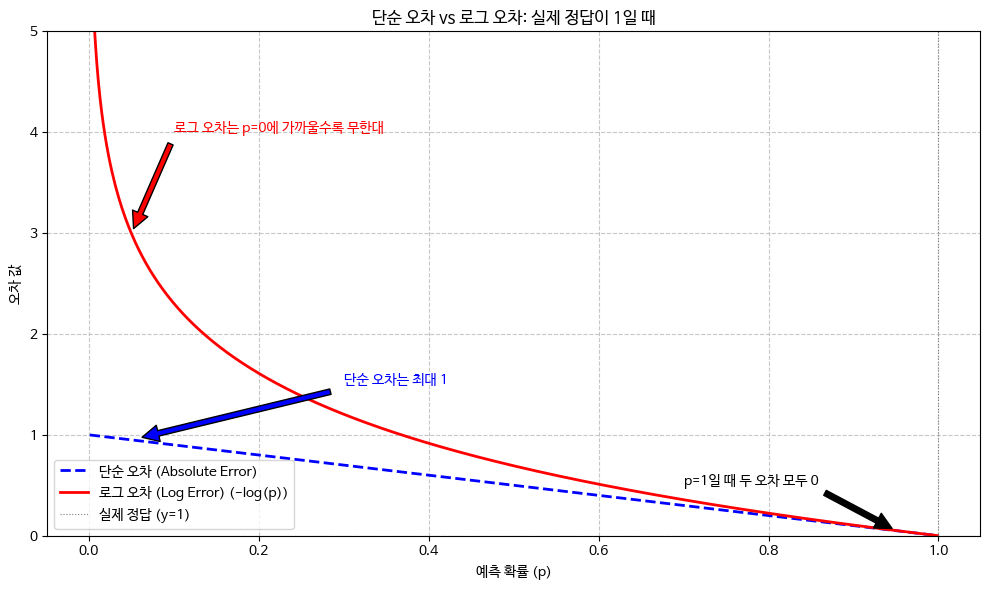

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 013 Visualization: Logistic Value Error Table ---

# 실제 정답: 1 (y=1)
y_true = 1

# 예측 확률 (p) 범위: 0.001부터 0.999까지 (log(0)을 피하기 위함)
p_range = np.linspace(0.001, 0.999, 500)

# 1. 단순 오차 (Absolute Error): abs(y_true - p)
absolute_error = np.abs(y_true - p_range)

# 2. 로그 오차 (Log Error) when y_true = 1: -log(p)
log_error = -np.log(p_range)

fig = plt.figure(figsize=(10, 6))
plt.plot(p_range, absolute_error, label='단순 오차 (Absolute Error)', color='blue', linestyle='--', linewidth=2)
plt.plot(p_range, log_error, label='로그 오차 (Log Error) (-log(p))', color='red', linewidth=2)

plt.axvline(y_true, color='gray', linestyle=':', linewidth=0.8, label=f'실제 정답 (y={y_true})')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)

plt.title('단순 오차 vs 로그 오차: 실제 정답이 1일 때')
plt.xlabel('예측 확률 (p)')
plt.ylabel('오차 값')
plt.ylim(0, 5) # Y축 범위를 제한하여 시각화 개선
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Annotations
plt.annotate('로그 오차는 p=0에 가까울수록 무한대', xy=(0.05, -np.log(0.05)), xytext=(0.1, 4),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=10, color='red')
plt.annotate('단순 오차는 최대 1', xy=(0.05, np.abs(y_true - 0.05)), xytext=(0.3, 1.5),
             arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=10, color='blue')
plt.annotate('p=1일 때 두 오차 모두 0', xy=(0.95, -np.log(0.95)), xytext=(0.7, 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.tight_layout()
plt.show()

### 그래프 해석: 단순 오차(Absolute Error) vs 로그 오차(Log Error) 비교

위 그래프는 실제 정답 `y`가 1일 때 (요리가 '맛있다'고 평가받았을 때), 주방장(모델)의 예측 확률 `p`에 따라 '단순 오차'와 '로그 오차'가 어떻게 달라지는지 시각적으로 보여줍니다.

*   **파란색 점선: 단순 오차 (Absolute Error)**
    *   단순 오차는 `|실제 정답 - 예측 확률|`로 계산됩니다. 이 오차는 예측 확률 `p`가 0에 가까워질수록 최대값인 1에 수렴합니다. 즉, 아무리 잘못 예측해도 오차의 최대값은 1을 넘지 않습니다.
    *   이는 모델이 크게 틀렸다고 하더라도 벌점이 선형적으로 증가하거나 특정 값(1)을 넘지 않는다는 것을 의미합니다. 예측이 완전히 틀려도 벌점이 '아주 크게' 증가하지는 않습니다.

*   **빨간색 실선: 로그 오차 (Log Error) (y=1일 때 -log(p))**
    *   로그 오차는 예측 확률 `p`가 1에 가까워질수록 0에 수렴합니다. 모델이 정확하게 예측하면 벌점이 거의 없습니다.
    *   하지만 예측 확률 `p`가 0에 가까워질수록 **로그 오차는 무한대로 급격하게 발산**합니다. 이는 모델이 실제 정답이 1인데도 불구하고, 이를 '거의 아니다' (p가 0에 가까움)라고 확신하여 예측하면 엄청나게 큰 벌점을 받는다는 것을 의미합니다.

**핵심 요약:**
이 그래프는 **로그 오차가 모델의 '확신도(confidence)'까지 고려하여 벌점을 매긴다**는 것을 명확히 보여줍니다. 단순 오차는 예측이 아무리 잘못되어도 벌점의 상한이 있지만, 로그 오차는 모델이 **강하게 확신했지만 틀린 예측**에 대해 기하급수적으로 큰 페널티를 주어, 모델이 극단적인 오판을 피하고 항상 신중하고 정확하게 예측하도록 강력하게 유도합니다. 딥러닝에서 이러한 로그 오차의 특성은 모델이 조금이라도 잘못된 예측을 했을 때 이를 심각하게 받아들이고 학습하도록 하는 중요한 역할을 합니다.


**수학적 의미:**  
예측값이 줄어들수록 단순 오차(y−y′)보다 로그 오차(log y′)가 더 빠르게 커짐.  

**생활 비유:**  
“틀린 답을 조금씩 더 틀리게 하면 벌점이 기하급수적으로 커지는 시험.”  

**딥러닝 연결:**  
로그 오차는 **작은 확률 예측에 큰 페널티**를 주어 모델이 정답 확률을 높이는 방향으로 학습하게 만듭니다.  

In [ ]:
import math

# 실제 정답: 1 (요리가 '맛있다')
실제_값_y = 1

# 주방장(모델)의 다양한 예측 확률
예측_확률_리스트 = [
    0.9,   # 거의 정답으로 예측
    0.8,   # 조금 벗어남
    0.5,   # 반반
    0.2,   # 많이 벗어남
    0.1,   # 매우 많이 벗어남
    0.01   # 거의 오답으로 강하게 예측
]

print("예측 확률 (p) | 단순 오차 (절대값) | 로그 오차 (-log(p))")
print("----------------------------------------------------------------")
for p in 예측_확률_리스트:
    # 단순 오차 (절대값): 실제값과 예측값의 차이
    단순_오차 = abs(실제_값_y - p)

    # 로그 오차 (크로스 엔트로피의 y=1일 때): -log(p)
    로그_오차 = -math.log(p)

    print(f"{p:13.2f} | {단순_오차:15.2f} | {로그_오차:18.2f}")

# 결과 해석:
# 1. 단순 오차는 예측이 틀려도 크게 증가하지 않습니다.
# 2. 로그 오차는 예측이 실제 정답에서 멀어질수록(p가 0에 가까워질수록) 기하급수적으로 커지는 것을 볼 수 있습니다.
# 즉, 주방장이 '이건 분명 완벽해!'라고 강하게 확신했지만 아주 조금이라도 틀렸을 때, 로그 오차는 훨씬 더 큰 벌점을 줍니다.

예측 확률 (p) | 단순 오차 (절대값) | 로그 오차 (-log(p))
----------------------------------------------------------------
         0.90 |            0.10 |               0.11
         0.80 |            0.20 |               0.22
         0.50 |            0.50 |               0.69
         0.20 |            0.80 |               1.61
         0.10 |            0.90 |               2.30
         0.01 |            0.99 |               4.61


#### 💡 확인 문제: 013. 로지스틱 값 오차표

Q1. 모델이 확신했지만 약간 틀린 예측을 했을 때, '단순 오차'와 비교하여 '로그 오차'는 어떻게 벌점을 부여하나요?

Q2. 실제 정답이 1인데 모델이 0.1로 예측한다면, '단순 오차'와 '로그 오차' 중 어떤 오차가 훨씬 더 큰 값을 가지나요?

Q3. 로그 오차(Log Error)는 딥러닝 모델에게 예측 확신도에 대해 어떤 행동을 권장하나요?

✅ **정답**

Q1. 단순 오차는 예측이 틀려도 크게 증가하지 않는 반면, 로그 오차는 예측이 틀릴수록 기하급수적으로 커지는 훨씬 더 큰 벌점을 부여합니다.

Q2. '로그 오차'가 훨씬 더 큰 값을 가집니다 (예시에서는 단순 오차 0.90, 로그 오차 2.30).

Q3. 모델이 작은 오차라도 무시하지 않고, 예측에 대한 확신도를 더 신중하게 가지도록 훈련시킵니다.


<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>




### 014: -log(1-y) vs log(1-y)  

### 👨‍🍳 '정답이 아닌 요리'를 맞히는 자의 점수 (y=0일 때): -log(1-y) vs log(1-y)

손님(정답)이 '이 요리는 절대 아니야!' (y=0)라고 말했을 때, 주방장(모델)의 예측은 어떠해야 할까요? 당연히 '전혀 아니다!'에 가깝게 예측할수록 좋습니다. 하지만 주방장이 '전혀 아니다!'라고 해야 할 요리를 '완벽하다!'에 가깝게 예측한다면 어떻게 될까요?

이런 상황에서 **'-로그(1-y)'** 는 벌점을 계산하는 또 다른 중요한 방식입니다. 주방장이 '정답이 아닌 요리'를 '정답'에 가깝게 예측할수록 벌점은 끝없이 커집니다. 반대로 '전혀 아니다!'에 가깝게 예측하면 벌점은 거의 없습니다. 이 시스템은 주방장이 '정답이 아닌 것'에 대해 잘못된 확신을 갖지 않도록 강력하게 교육합니다.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


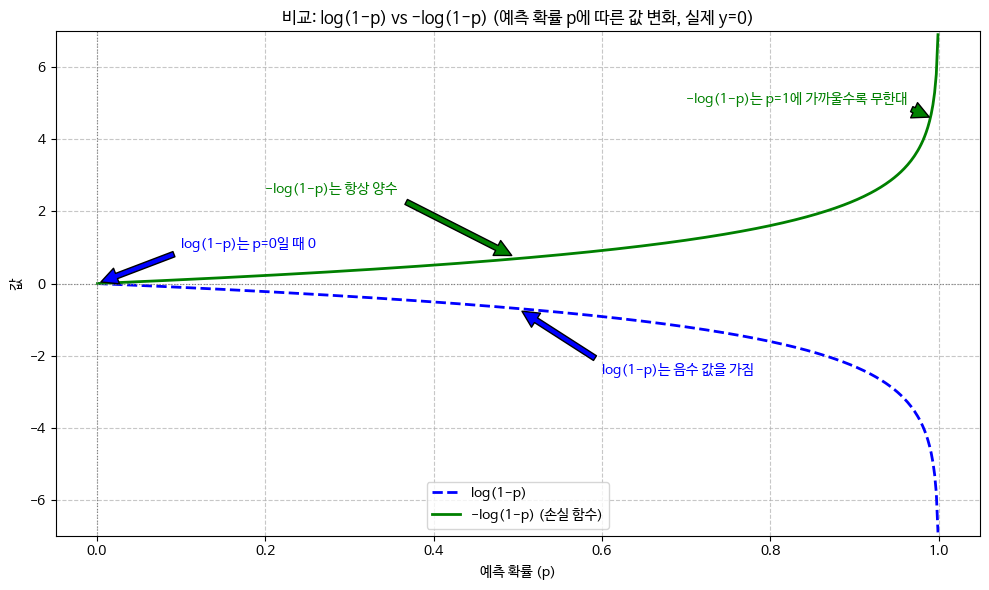

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# matplotlib 한글 폰트 설정 (이전 셀에서 이미 설정되었을 수 있으나, 재확보 차원에서 포함)
if 'COLAB_GPU' in os.environ:
    !apt-get update -qq
    !apt-get install fonts-nanum -qq > /dev/null
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
    plt.rc('font', family='NanumBarunGothic') # Colab에서 NanumBarunGothic 폰트 사용
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- Section 014 Visualization: -log(1-y) vs log(1-y) ---

# Predicted probability (p) ranging from a very small number to 1 - epsilon to avoid log(0)
p_range = np.linspace(0.001, 0.999, 500)

# We are interested in the behavior when y=0. So we analyze log(1-p) and -log(1-p)
log_1_minus_p = np.log(1 - p_range)
minus_log_1_minus_p = -np.log(1 - p_range)

fig = plt.figure(figsize=(10, 6))
plt.plot(p_range, log_1_minus_p, label='log(1-p)', color='blue', linestyle='--', linewidth=2)
plt.plot(p_range, minus_log_1_minus_p, label='-log(1-p) (손실 함수)', color='green', linewidth=2)

plt.axhline(0, color='gray', linestyle=':', linewidth=0.8) # 0점 기준선
plt.axvline(0, color='gray', linestyle=':', linewidth=0.8) # p=0 기준선

plt.title('비교: log(1-p) vs -log(1-p) (예측 확률 p에 따른 값 변화, 실제 y=0)')
plt.xlabel('예측 확률 (p)')
plt.ylabel('값')
plt.ylim(-7, 7) # Y축 범위를 제한하여 시각화 개선
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Annotations
plt.annotate('log(1-p)는 음수 값을 가짐', xy=(0.5, np.log(1-0.5)), xytext=(0.6, -2.5),
             arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=10, color='blue')
plt.annotate('log(1-p)는 p=0일 때 0', xy=(0, np.log(1-0.001)), xytext=(0.1, 1),
             arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=10, color='blue')

plt.annotate('-log(1-p)는 항상 양수', xy=(0.5, -np.log(1-0.5)), xytext=(0.2, 2.5),
             arrowprops=dict(facecolor='green', shrink=0.05), fontsize=10, color='green')
plt.annotate('-log(1-p)는 p=1에 가까울수록 무한대', xy=(0.99, -np.log(1-0.99)), xytext=(0.7, 5),
             arrowprops=dict(facecolor='green', shrink=0.05), fontsize=10, color='green')

plt.tight_layout()
plt.show()

### 그래프 해석: `log(1-p)` vs `-log(1-p)` (예측 확률 p에 따른 값 변화, 실제 y=0일 때)

위 그래프는 실제 정답 `y`가 0일 때 (즉, 손님이 '이 요리는 맛없다'고 평가했을 때), 주방장(모델)의 예측 확률 `p`에 따라 일반적인 로그 함수 `log(1-p)`와 딥러닝 손실 함수에서 주로 사용하는 `-log(1-p)`의 값이 어떻게 변화하는지를 비교하여 보여줍니다. 이는 모델이 '오답'인 경우에 대한 예측을 어떻게 평가하는지 이해하는 데 중요합니다.

*   **파란색 점선: `log(1-p)`**
    *   `p`가 0에 가까워질수록 (즉, 모델이 '맛없다'고 예측할수록) `1-p`는 1에 가까워지므로 `log(1-p)`는 0에 수렴합니다.
    *   `p`가 1에 가까워질수록 (즉, 모델이 '맛있다'고 예측할수록) `1-p`는 0에 가까워지므로 `log(1-p)`는 음의 무한대(`-∞`)로 발산합니다.
    *   `log(1-p)`는 대부분의 `p` 값에서 음수 값을 가지므로, 직접적으로 '벌점'으로 사용하기에는 부적합합니다. (벌점은 항상 양수여야 합니다.)

*   **초록색 실선: `-log(1-p)` (딥러닝 손실 함수의 핵심)**
    *   이 그래프는 `log(1-p)` 그래프를 x축에 대해 뒤집어 놓은 형태입니다.
    *   `p`가 0에 가까워질수록 `-log(1-p)`는 0에 수렴합니다. 이는 모델이 실제 정답이 0임을 매우 정확하게 예측했을 때 벌점이 거의 없다는 것을 의미합니다. (예: '맛없다'고 예측했는데 실제 '맛없는' 경우, 벌점 없음).
    *   **수학적 의미:** `p`가 1에 가까워질수록 `-log(1-p)`는 양의 무한대(`+∞`)로 급격하게 발산합니다. 이는 모델이 실제 정답(`y=0`)임에도 불구하고 '정답이다' (즉, `p`가 1에 가까움)라고 강하게 예측하면 엄청나게 큰 벌점을 받는다는 것을 의미합니다. (예: '맛없는' 요리를 '맛있다'고 강하게 예측하면 엄청난 벌점).

**핵심 요약:**
딥러닝에서 `y=0`일 때의 손실 함수는 `p`가 1에 가까워질수록 무한대로 발산하는 `-log(1-p)`를 사용합니다. 이는 모델이 **'오답'인 상황에서 잘못된 예측을 강력하게 확신하면 매우 큰 페널티**를 주어, 모델이 신중하고 정확하게 부정 예측을 하도록 강력하게 유도하는 역할을 합니다.



**수학적 의미:**  
- \( \log(1-y) \): 음수  
- \( -\log(1-y) \): \( y \)가 1에 가까울수록 값이 커짐  

**생활 비유:**  
“정답이 0인데 1에 가깝게 예측하면 벌점 폭발.”  

**딥러닝 연결:**  
Binary Classification에서 **y=0일 때의 손실**을 설명하는 그래프입니다.

<br/>

### 🦍 딥러닝에서의 역할 (1):
실제 정답이 0인 경우(부정 클래스), 딥러닝 모델의 예측 확률이 0에 가까울수록 손실을 거의 주지 않고, 1에 가까울수록 무한대에 가까운 큰 손실을 주어 정확한 부정 예측을 유도합니다.

### 🦍 더 쉽게 풀어보는 딥러닝 예시 (2):
손님이 '이 요리는 절대 아니야!(정답 0)'라고 했을 때, 주방장이 '절대 아닙니다!(예측 0)'라고 예측하면 칭찬(손실 없음), '완벽합니다!(예측 1)'라고 예측하면 엄청난 벌점(무한대 손실)을 받는 것과 같습니다.

### 🦍 더더 쉽게 풀어보는 딥러닝 예시 (3):
오답인 문제를 정확히 오답으로 판단하면 점수를 얻지만, 오답인데 정답으로 강하게 찍으면 엄청난 감점을 받는 시험 채점 방식과 같습니다.

In [ ]:
import math

# 실제 정답: 0 (예: 이 요리는 '맛없다')
실제_값_y = 0

# 주방장(모델)의 예측 확률 (0과 1 사이의 값)
예측_p_아주정확 = 0.01  # '맛없다'고 아주 강하게 예측
예측_p_중간 = 0.50     # '맛없다'고 반반으로 예측
예측_p_아주틀림 = 0.99  # '맛있다'고 아주 강하게 예측 (오판)

# 로그 손실 계산 (y=0일 때): -log(1-p)
손실_아주정확 = -math.log(1 - 예측_p_아주정확)
손실_중간 = -math.log(1 - 예측_p_중간)
손실_아주틀림 = -math.log(1 - 예측_p_아주틀림)

print(f"실제 정답 (y): {실제_값_y} (요리는 맛없다)")
print("----------------------------------")
print(f"예측 확률 0.01: 손실 = {손실_아주정확:.2f} (거의 벌점 없음)")
print(f"예측 확률 0.50: 손실 = {손실_중간:.2f} (중간 벌점)")
print(f"예측 확률 0.99: 손실 = {손실_아주틀림:.2f} (매우 큰 벌점!)")

# 실제 정답이 '0'인데, 주방장이 '1'에 가깝게 예측할수록 벌점이 엄청나게 커지는 것을 볼 수 있습니다.
# 이는 모델이 정답이 아닌 상황에서 잘못된 예측을 강력하게 피하도록 만듭니다.

실제 정답 (y): 0 (요리는 맛없다)
----------------------------------
예측 확률 0.01: 손실 = 0.01 (거의 벌점 없음)
예측 확률 0.50: 손실 = 0.69 (중간 벌점)
예측 확률 0.99: 손실 = 4.61 (매우 큰 벌점!)


#### 💡 확인 문제: 014. -log(1-y) vs log(1-y)

Q1. 실제 정답이 0(예: '이 요리는 맛없어!')일 때, 모델이 0에 매우 가까운 확률(예: 0.01)로 예측한다면 로그 손실(Log Loss) 벌점은 대략 얼마가 되나요?

Q2. 반대로 실제 정답이 0인데 모델이 1에 매우 가까운 확률(예: 0.99)로 예측한다면 로그 손실 벌점은 어떻게 되나요?

Q3. `y=0`인 경우, 확신하지만 틀린 예측에 대해 '무한대에 가까운 벌점'을 주는 것은 모델에게 어떤 학습 효과를 가져오나요?

✅ **정답**

Q1. 거의 벌점이 없습니다 (예시에서는 0.01).

Q2. 무한대에 가까운 매우 큰 벌점을 받습니다 (예시에서는 4.61).

Q3. 모델이 '오답'인 상황에서 절대 엉뚱한 예측을 하지 않도록 강력하게 유도하고, 정확한 부정 예측을 하도록 훈련시킵니다.

<br/>
<br/>
<br/>
<br/>

---

<br/>
<br/>
<br/>
<br/>



### 🚀 핵심 개념 최종 정리

지금까지 우리 딥러닝 주방의 복잡한 요리 과정과 맛 평가 도구들을 살펴보았습니다. 주방장(모델)이 최고의 요리를 만들 수 있도록 도와주는 핵심 개념들을 다시 한번 짚어볼까요?

01. **크로스 엔트로피 손실 함수 (Cross Entropy Loss)**
    *   **핵심:** 주방장(모델)이 만든 요리(예측)가 손님(정답)의 입맛에 얼마나 맞지 않는지(틀렸는지)를 엄격하게 점수 매기는 심사위원입니다. 특히 '완전히 틀렸다'고 강하게 예측할수록 벌점을 아주 크게 줍니다.
    *   **딥러닝에서:** 모델의 예측이 실제 정답과 얼마나 다른지 측정하여, 모델이 학습해야 할 방향과 크기를 알려주는 가장 중요한 지표입니다.

02. **멀티 클래스 (Multi-Class) vs 멀티 라벨 (Multi-Label)**
    *   **핵심:** 요리 대회가 '여러 요리 중 최고 한 가지 요리'를 뽑는지 (멀티 클래스), 아니면 '하나의 요리가 여러 특징을 동시에 가질 수 있는지' (멀티 라벨)를 구분하는 방식입니다.
    *   **딥러닝에서:** 문제의 종류에 따라 모델이 답을 하나만 고를지, 여러 답을 동시에 고를지 결정하는 기준입니다.

03. **소프트맥스 (Softmax) & 시그모이드 (Sigmoid)**
    *   **핵심:** 주방장의 '직감' 점수를 '이 요리가 성공할 확률은 몇 %!'처럼 숫자로 정확한 확률로 바꿔주는 도구입니다. 소프트맥스는 여러 요리 중 하나의 확률을, 시그모이드는 각 요리의 성공 확률을 독립적으로 알려줍니다.
    *   **딥러닝에서:** 모델의 마지막 출력 값을 0과 1 사이의 '확률'로 변환하여 해석하기 쉽게 만듭니다. (멀티 클래스엔 Softmax, 이진/멀티 라벨엔 Sigmoid)

04. **미분 (Derivative) & 역전파 (Backpropagation)**
    *   **핵심:** 요리가 맛이 없을 때, '어떤 재료를 얼마나 줄이거나 늘려야 다음엔 더 맛있을까?'를 알려주는 '맛 조절 지침서'입니다. 이 지침을 따라서 재료의 양(가중치)을 조절하는 과정이 반복됩니다.
    *   **딥러닝에서:** 모델의 예측 오류(손실)를 줄이기 위해, 각 가중치(모델의 내부 값)를 어떤 방향으로 얼마나 변경해야 할지 계산하여 모델을 똑똑하게 만드는 핵심 기술입니다.

05. **로그 손실 (Log Loss)의 경고**
    *   **핵심:** 주방장이 '이 요리는 100% 매울 거야!'라고 확신했는데, 실제로는 '전혀 안 매운' 요리였다면 '상상 초월의 벌점'을 줘서 극단적인 오판을 강력하게 막는 규칙입니다.
    *   **딥러닝에서:** 모델이 잘못된 예측에 너무 강하게 확신할 때, 엄청나게 큰 손실을 부여하여 모델이 신중하게 예측하도록 훈련하는 강력한 장치입니다.

이 개념들을 이해한다면, 우리 딥러닝 주방장(모델)이 어떻게 요리(예측)를 배우고, 실수에서 더 나은 요리를 만들어내는지 그 비밀을 파헤칠 수 있을 거예요! 👩‍🍳